<br>
<div style="text-align:center;">
    <span style="color:#99BBF4; font-size:33px; font-weight:bold;">
       NOTEBOOK 4 v1.0. MODELO BILSTM SOBRE ESPECTROGRAMAS MEL PARA CLASIFICACIÓN ALS VS HC (CV 5-FOLD + ENSEMBLE)
    </span>
</div>

<div style="text-align:center;">
    <span style="color:#6593BA; font-size:22px; font-weight:bold;">
        Trabajo Fin de Grado
    </span>
    <br>
    <span style="color:#6593BA; font-size:20px; font-weight:bold;">
        Ingeniería Biomédica Curso 2025/2026
    </span>
</div>
<br>

<br>
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">
        ÍNDICE
    </span>
</div>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       INTRODUCCIÓN
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
        1. Objetivo del notebook y relación con notebooks anteriores
        <br>
        2. Configuración técnica y variables globales
        <br>
</span>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       BLOQUE 1. CARGA Y ANÁLISIS EXPLORATORIO DE LOS TENSORES
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
        3. Carga y verificación de los tensores preprocesados
        <br>
        4. Análisis exploratorio: distribución de duraciones y clases
        <br>
        5. Visualización comparativa ALS vs HC
        <br>
</span>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       BLOQUE 2. PREPARACIÓN PARA DEEP LEARNING
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
        6. Dataset personalizado (PyTorch Dataset)
        <br>
        7. Estrategia de padding y collate_fn
        <br>
        8. DataLoaders y class weights
        <br>
</span>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       BLOQUE 3. DEFINICIÓN DEL MODELO BiLSTM
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
        9. Justificación de la arquitectura BiLSTM
        <br>
        10. Implementación del modelo
        <br>
        11. Diagrama de arquitectura y dimensiones
        <br>
        12. Recuento de parámetros
        <br>
</span>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       BLOQUE 4. ENTRENAMIENTO CON MLFLOW
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
        13. Configuración de MLflow
        <br>
        14. Función de pérdida, optimizador y scheduler
        <br>
        15. Bucle de entrenamiento instrumentado
        <br>
        16. Curvas de entrenamiento
        <br>
</span>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       BLOQUE 5. EVALUACIÓN EN VALIDATION
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
        17. Métricas globales OOF (CV 5-fold)
        <br>
        18. Evaluación OOF a nivel de sujeto
        <br>
        19. Matriz de confusión OOF
        <br>
        20. Curva ROC y distribución de probabilidades (OOF)
        <br>
</span>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       BLOQUE 6. EVALUACIÓN EN TEST
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
        21. Evaluación completa en Test Set
        <br>
        22. Matriz de confusión
        <br>
        23. Curva ROC y distribución de probabilidades
        <br>
</span>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       BLOQUE 7. EXPLICABILIDAD
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
        24. Saliency maps sobre espectrogramas
        <br>
        25. Interpretación clínica de las regiones relevantes
        <br>
        26. PCA y t-SNE de embeddings BiLSTM
        <br>
</span>

<div style="text-align:LEFT;">
    <span style="color:#99BBF4; font-size:20px; font-weight:bold;">
       CONCLUSIONES
    </span>
</div>

<span style="color:#6593BA; font-size:20px; font-weight:bold; font-family: Calibri;">
        27. Discusión de resultados y limitaciones
        <br>
        28. Conclusiones del notebook
        <br>
</span>

#
---
#
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">
        INTRODUCCIÓN
    </span>

<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 1. Objetivo del notebook y relación con notebooks anteriores</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">

Este notebook desarrolla el <b>HITO 3</b> del proyecto y constituye el primer núcleo del componente de Deep Learning del TFG. Su objetivo es entrenar, evaluar e interpretar un modelo de red neuronal recurrente (concretamente una <b>LSTM bidireccional (BiLSTM)</b>) capaz de distinguir entre pacientes con Esclerosis Lateral Amiotrófica (ALS) y controles sanos (HC) a partir de <b>espectrogramas log-Mel</b> generados en el Notebook 3.
<br><br>
La elección de una arquitectura recurrente no es arbitraria. A diferencia de las redes convolucionales, que procesan el espectrograma como una imagen 2D capturando correlaciones locales en tiempo y frecuencia, las redes LSTM están diseñadas para modelar <b>dependencias temporales de largo alcance</b>. Esta propiedad es particularmente relevante en el análisis vocal patológico: la disartria asociada a la ALS no se manifiesta en un único instante del espectrograma, sino que genera <b>patrones de degradación progresiva</b> a lo largo de la fonación (pérdida gradual de energía en formantes, irregularidades rítmicas en diadococinesia, reducción de la modulación espectral) que solo son capturables si el modelo tiene memoria temporal explícita.
<br><br>
La arquitectura bidireccional extiende esta capacidad al procesar la secuencia tanto en dirección directa (pasado → futuro) como inversa (futuro → pasado), de modo que la representación de cada instante temporal incorpora contexto completo de la señal. Para tareas de clasificación de secuencias completas (como la que nos ocupa, donde la etiqueta es única por audio) el procesamiento bidireccional ha demostrado empíricamente mejoras en recall sobre la clase patológica.
<br><br>
<b>Relación con notebooks anteriores:</b>
<ul>
<li><b>Notebook 1 (Validación):</b> Estableció el split 70/15/15 por sujeto, con verificación de no leakage. El presente notebook consume <code>subject_split.csv</code> únicamente como referencia de etiquetas, sin modificarlo.</li>
<li><b>Notebook 3 (Preprocesamiento):</b> Generó los tensores <code>.pt</code> normalizados con estadísticos de Train. El pipeline de preprocesamiento está completamente congelado: este notebook no modifica ni regenera ningún tensor.</li>
<li><b>Notebook 2 (Random Forest):</b> Proporcionó una línea base con variables acústicas handcrafted. El modelo BiLSTM aprende directamente de la representación en bruto (espectrograma), sin selección manual de features, lo que permite evaluar si el aprendizaje end-to-end supera al enfoque clásico.</li>
</ul>
<br>
<b>Métrica principal:</b> dado el desequilibrio de clases (2:1, ALS:HC) y la asimetría del coste clínico (un falso negativo en ALS implica ausencia de tratamiento temprano), la métrica primaria de optimización es el <b>Recall ALS</b>, con balanced accuracy y ROC-AUC como métricas secundarias.
    </span>
</div>

<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 2. Configuración técnica y variables globales</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">

Se importan todas las dependencias necesarias y se fijan los hiperparámetros globales del experimento. La semilla <code>SEED = 42</code> se propaga a Python, NumPy, PyTorch y CUDA para garantizar reproducibilidad estricta. En el contexto de Deep Learning, la reproducibilidad no se limita a la inicialización de pesos: afecta también al orden de los batches (DataLoader), a las operaciones no deterministas de CUDA y a la inicialización del estado oculto de la LSTM.
<br><br>
Los parámetros del espectrograma (<code>N_MELS=128</code>, <code>N_FFT=2048</code>, <code>HOP_LENGTH=512</code>) se declaran aquí por coherencia con el Notebook 3, pero <b>no se aplican</b>: los tensores ya están preprocesados y normalizados. Su presencia sirve únicamente como documentación de la configuración de entrada al modelo.
    </span>
</div>

In [1]:
# CONFIGURACIÓN DEL ENTORNO
import os
import sys
import json
import random
import warnings
import yaml
from pathlib import Path
from datetime import datetime
from collections import defaultdict
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm import tqdm
 
# Deep Learning
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence, pad_sequence
 
# Métricas
from sklearn.metrics import (
    balanced_accuracy_score, recall_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve,
    classification_report
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
 
# MLflow
import mlflow
import mlflow.pytorch
 
warnings.filterwarnings("ignore")
 
print("Librerías importadas correctamente.")
print(f"PyTorch versión : {torch.__version__}")
print(f"CUDA disponible : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo en uso : {device}")
 
if device.type == "cuda":
    print(f"GPU activa        : {torch.cuda.get_device_name(0)}")
    print(f"Memoria reservada : {torch.cuda.memory_reserved(0)/1024**2:.2f} MB")

c:\Users\Laura\OneDrive\TFG\.venv310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Librerías importadas correctamente.
PyTorch versión : 2.5.1+cu121
CUDA disponible : True
GPU             : NVIDIA GeForce RTX 2050
Dispositivo en uso : cuda
GPU activa        : NVIDIA GeForce RTX 2050
Memoria reservada : 0.00 MB


In [2]:
SEED = 42

def set_seed(seed: int = SEED):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(SEED)


def load_config():
    """Busca config.yaml hacia arriba desde CWD o via env var TFG_CONFIG."""
    cfg_path = os.environ.get("TFG_CONFIG")
    if cfg_path is None:
        for parent in [Path.cwd(), *Path.cwd().parents]:
            if (parent / "config.yaml").exists():
                cfg_path = parent / "config.yaml"
                break
    if cfg_path is None:
        raise FileNotFoundError(
            "No se encuentra config.yaml. Crea uno en la raíz del repo o define TFG_CONFIG."
        )
    with open(cfg_path) as f:
        cfg = yaml.safe_load(f)
    root = Path(cfg_path).resolve().parent
    for k, v in cfg["paths"].items():
        p = Path(v)
        cfg["paths"][k] = str((root / p).resolve()) if not p.is_absolute() else str(p)
    return cfg


CONFIG = load_config()

# RUTAS
PREPROCESSED_PATH = Path(CONFIG["paths"]["preprocessed"])
SPLIT_PATH        = Path(CONFIG["paths"]["splits"]) / "subject_split.csv"
RESULTS_PATH      = Path(CONFIG["paths"]["results"]) / "04_bilstm_v1_2"
MLRUNS_PATH       = RESULTS_PATH / "mlruns"
MODELS_PATH       = RESULTS_PATH / "models"
FIGS_PATH         = RESULTS_PATH / "figures"

for p in [RESULTS_PATH, MLRUNS_PATH, MODELS_PATH, FIGS_PATH]:
    p.mkdir(parents=True, exist_ok=True)

# IDs de columnas
ID_COL     = CONFIG["dataset"]["id_col"]
TARGET_COL = CONFIG["dataset"]["target_col"]

# Parámetros del espectrograma (desde config.yaml)
SR         = CONFIG["audio"]["sr"]
N_FFT      = CONFIG["audio"]["n_fft"]
HOP_LENGTH = CONFIG["audio"]["hop_length"]
N_MELS     = CONFIG["audio"]["n_mels"]

# HIPERPARÁMETROS DEL MODELO (desde config.yaml)
HIDDEN_SIZE     = CONFIG["bilstm"]["hidden_size"]
NUM_LAYERS      = CONFIG["bilstm"]["num_layers"]
DROPOUT         = CONFIG["bilstm"]["dropout"]
BIDIRECTIONAL   = CONFIG["bilstm"]["bidirectional"]
MAX_SEQ_LEN     = CONFIG["bilstm"]["max_seq_len"]
BATCH_SIZE      = CONFIG["bilstm"]["batch_size"]
LEARNING_RATE   = CONFIG["bilstm"]["learning_rate"]
NUM_EPOCHS      = CONFIG["bilstm"]["num_epochs"]
PATIENCE        = CONFIG["bilstm"]["patience"]
WEIGHT_DECAY    = CONFIG["bilstm"]["weight_decay"]
LABEL_SMOOTHING = CONFIG["bilstm"]["label_smoothing"]

CLASS_NAMES = ["HC", "ALS"]
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"\nDevice activo : {DEVICE}")
print(f"Directorio de resultados: {RESULTS_PATH.resolve()}")
print(f"\n{'═'*55}")
print(f"  CONFIGURACIÓN v1.2 — CV 5-fold + diagnóstico colapso")
print(f"{'═'*55}")
print(f"  HIDDEN_SIZE     = {HIDDEN_SIZE}")
print(f"  NUM_LAYERS      = {NUM_LAYERS}")
print(f"  DROPOUT         = {DROPOUT}")
print(f"  MAX_SEQ_LEN     = {MAX_SEQ_LEN}")
print(f"  BATCH_SIZE      = {BATCH_SIZE}")
print(f"  LEARNING_RATE   = {LEARNING_RATE}")
print(f"  PATIENCE        = {PATIENCE}")
print(f"  WEIGHT_DECAY    = {WEIGHT_DECAY}")
print(f"  LABEL_SMOOTHING = {LABEL_SMOOTHING}")
print(f"{'═'*55}")



Device activo : cuda
Directorio de resultados: C:\Users\Laura\OneDrive\TFG\results\04_bilstm_v1_2

═══════════════════════════════════════════════════════
  CONFIGURACIÓN v1.2 — CV 5-fold + diagnóstico colapso
═══════════════════════════════════════════════════════
  HIDDEN_SIZE     = 32
  NUM_LAYERS      = 1
  DROPOUT         = 0.5
  MAX_SEQ_LEN     = 400
  BATCH_SIZE      = 16
  LEARNING_RATE   = 0.0005
  PATIENCE        = 15
  WEIGHT_DECAY    = 0.01
  LABEL_SMOOTHING = 0.1
═══════════════════════════════════════════════════════


#
---
#
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">BLOQUE 1. CARGA Y ANÁLISIS EXPLORATORIO DE LOS TENSORES</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">

Antes de definir cualquier arquitectura de red, es imprescindible caracterizar estadísticamente los datos de entrada tal como los verá el modelo. Este bloque carga los tensores <code>.pt</code> generados en el Notebook 3 y realiza un análisis exploratorio orientado a tres cuestiones metodológicamente importantes para el diseño del modelo:

<ol>
<li><b>Variabilidad de longitud:</b> Los espectrogramas tienen duración variable porque la señal de voz de cada sujeto tiene duración diferente (influenciada, en el caso de ALS, por la propia enfermedad). Esta variabilidad es la razón fundamental por la que se elige una arquitectura recurrente en lugar de una red fully connected o una CNN con entrada de tamaño fijo: la LSTM procesa secuencias de longitud arbitraria de forma natural.</li>
<li><b>Balance de clases en cada partición:</b> Verificar que el split por sujeto (diseñado en el Notebook 1 con estratificación) mantiene una proporción ALS/HC similar en train, val y test es crítico para que el umbral de decisión estimado en validación sea transferible a test.</li>
<li><b>Diferencias espectrales ALS vs HC:</b> La visualización de espectrogramas promedio por clase permite formular hipótesis sobre qué regiones del espectrograma (bandas de frecuencia, intervalos temporales) son más discriminativas, información que se recuperará en el módulo de explicabilidad.</li>
</ol>
    </span>
</div>

<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 3. Carga y verificación de los tensores preprocesados</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">

Los tensores exportados en el Notebook 3 siguen la convención de nombrado <code>{subject_id}_{task}.pt</code> y se organizan en subdirectorios <code>train/</code>, <code>val/</code> y <code>test/</code>. Cada tensor tiene forma <code>(128, T)</code>, donde 128 es el número de bins Mel y T es el número de frames, variable entre archivos.
<br>
La carga se realiza con <code>torch.load(..., map_location='cpu')</code> para evitar conflictos de dispositivo: el traslado a GPU se realizará dentro del bucle de entrenamiento frame a frame. El split CSV proporciona las etiquetas diagnósticas (ALS=1, HC=0) para cada sujeto.
    </span>
</div>

In [3]:
def load_tensor_split(split_dirname: str, preprocessed_path: Path,
                       label_map: dict) -> list:
    """
    Carga todos los tensores .pt de un subdirectorio del preprocesado.

    Args:
        split_dirname:     Nombre de la subcarpeta ('cv' o 'test').
        preprocessed_path: Directorio raíz de tensores preprocesados.
        label_map:         Dict {subject_id: label} para resolver etiquetas.

    Returns:
        Lista de diccionarios {tensor, label, subject_id, task, n_frames}.
    """
    part_path = preprocessed_path / split_dirname

    records = []
    missing_label = 0
    invalid_file = 0

    pt_files = list(part_path.glob("*.pt")) if part_path.exists() else []

    for pt_file in sorted(pt_files):
        # Convención de nombre: {subject_id}_{task}.pt
        parts = pt_file.stem.rsplit("_", 1)
        subject_id = parts[0] if len(parts) == 2 else pt_file.stem
        task = parts[1] if len(parts) == 2 else "unknown"

        if subject_id not in label_map:
            missing_label += 1
            continue

        obj = torch.load(pt_file, map_location="cpu")

        if isinstance(obj, dict):
            if "spectrogram" not in obj:
                invalid_file += 1
                continue
            tensor = obj["spectrogram"].float()
        else:
            tensor = obj.float()

        # (1, N_MELS, T) -> (N_MELS, T)
        if tensor.ndim == 3 and tensor.shape[0] == 1:
            tensor = tensor.squeeze(0)

        if tensor.ndim == 2 and tensor.shape[0] != N_MELS and tensor.shape[1] == N_MELS:
            tensor = tensor.T

        if tensor.ndim != 2:
            invalid_file += 1
            continue

        label = int(label_map[subject_id])

        records.append({
            "tensor": tensor,
            "label": label,
            "subject_id": subject_id,
            "task": task,
            "n_frames": tensor.shape[1],
        })

    print(
        f"[{split_dirname.upper():5s}] {len(records):4d} tensores cargados | "
        f"{missing_label} sin etiqueta | {invalid_file} invalidos"
    )
    return records


# CARGA DEL CSV DE SPLIT (acepta formato nuevo CV+Test o legacy Train/Validation/Test)
split_df = pd.read_csv(SPLIT_PATH)

# Compatibilidad con split legacy: Train+Validation -> CV (igual que NB02 v1/v2 y NB03)
unique_splits = set(split_df["Split"].unique())
if "CV" not in unique_splits and {"Train", "Validation"}.issubset(unique_splits):
    print("[compat] Split legacy detectado — fusionando Train+Validation -> CV")
    split_df["Split"] = split_df["Split"].replace({"Train": "CV", "Validation": "CV"})

# Etiqueta binaria (ALS=1, HC=0)
split_df["label"] = (split_df[TARGET_COL].astype(str).str.upper().str.strip() == "ALS").astype(int)

print("\nDistribución por partición:")
print(split_df["Split"].value_counts().to_string())

cv_subjects   = split_df[split_df["Split"] == "CV"].copy().reset_index(drop=True)
test_subjects = split_df[split_df["Split"] == "Test"][ID_COL].tolist()

# GENERACIÓN DE FOLDS IN-MEMORY (StratifiedGroupKFold sobre los sujetos de CV)
# El split en disco no tiene columna Fold (split legacy), así que se genera aquí
# de forma análoga a NB02 v1/v2.
if "Fold" in cv_subjects.columns and cv_subjects["Fold"].notna().all():
    print("[ok] Folds pre-asignados en CSV — se usan directamente")
    cv_subjects["Fold"] = cv_subjects["Fold"].astype(int)
else:
    from sklearn.model_selection import StratifiedGroupKFold
    print("[compat] Folds no presentes — generando con StratifiedGroupKFold(5)")
    sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
    fold_col = np.full(len(cv_subjects), -1, dtype=int)
    X_cv = cv_subjects[[ID_COL]].values
    y_cv = cv_subjects["label"].values
    g_cv = cv_subjects[ID_COL].values
    for fi, (_, val_idx) in enumerate(sgkf.split(X_cv, y_cv, groups=g_cv)):
        fold_col[val_idx] = fi
    cv_subjects["Fold"] = fold_col
    assert (cv_subjects["Fold"] >= 0).all(), "Hay sujetos CV sin fold"

print("\nDistribución por fold:")
print(cv_subjects.groupby(["Fold", "label"]).size().unstack(fill_value=0))

# CARGA DE TENSORES DESDE preprocessed/cv y preprocessed/test
label_map = dict(zip(split_df[ID_COL], split_df["label"]))

cv_data   = load_tensor_split("cv",   PREPROCESSED_PATH, label_map)
test_data = load_tensor_split("test", PREPROCESSED_PATH, label_map)

# Adjuntar el fold a cada record de CV (necesario en bucle de entrenamiento)
fold_map = dict(zip(cv_subjects[ID_COL], cv_subjects["Fold"].astype(int)))
for r in cv_data:
    r["fold"] = fold_map[r["subject_id"]]

# Verificación de no fuga
cv_ids   = set(r["subject_id"] for r in cv_data)
test_ids = set(r["subject_id"] for r in test_data)
assert cv_ids.isdisjoint(test_ids), "LEAK CV ∩ Test"
print(f"\n✓ No leakage CV ∩ Test ({len(cv_ids)} sujetos CV, {len(test_ids)} Test)")


[compat] Split legacy detectado — fusionando Train+Validation -> CV

Distribución por partición:
Split
CV      130
Test     23
[compat] Folds no presentes — generando con StratifiedGroupKFold(5)

Distribución por fold:
label  0   1
Fold        
0      9  17
1      9  17
2      9  17
3      8  18
4      9  17
[CV   ] 1040 tensores cargados | 0 sin etiqueta | 0 invalidos
[TEST ]  184 tensores cargados | 0 sin etiqueta | 0 invalidos

✓ No leakage CV ∩ Test (130 sujetos CV, 23 Test)


<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 4. Análisis exploratorio: distribución de duraciones y clases</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">

La distribución de longitudes de secuencia tiene implicaciones directas sobre el diseño del <i>collate_fn</i> (función de agrupación de muestras en batch). Si la distribución es muy asimétrica (larga cola a la derecha con algunos archivos muy largos), el padding de las secuencias cortas hasta la longitud máxima del batch introduce una cantidad elevada de padding que puede degradar el aprendizaje. En ese caso, ordenar los batches por longitud descendente (<i>bucket batching</i>) reduce el padding promedio.
<br><br>
Adicionalmente, se examina la diferencia de duración entre grupos ALS y HC. Desde el punto de vista clínico, los pacientes con ALS suelen presentar velocidades de habla reducidas (bradilalia) y mayor esfuerzo fonatorio, lo que puede traducirse en diferencias sistemáticas en la duración de las grabaciones. Si este patrón se confirma estadísticamente, el modelo podría estar aprendiendo parcialmente a discriminar clases por duración en lugar de por contenido espectral, lo que constituiría un sesgo de confusión que debe monitorizarse.
    </span>
</div>

In [4]:
def summarize_split(data: list, split_name: str) -> pd.DataFrame:
    """Construye un DataFrame resumen de una partición."""
    rows = []
    for rec in data:
        duration_s = rec["n_frames"] * HOP_LENGTH / SR
        rows.append({
            "split":      split_name,
            "subject_id": rec["subject_id"],
            "task":       rec["task"],
            "label":      rec["label"],
            "class":      CLASS_NAMES[rec["label"]],
            "n_frames":   rec["n_frames"],
            "duration_s": round(duration_s, 3),
        })
    return pd.DataFrame(rows)

df_cv   = summarize_split(cv_data,   "cv")
df_test = summarize_split(test_data, "test")
df_all  = pd.concat([df_cv, df_test], ignore_index=True)

# Estadísticas de duración
print("\nEstadísticas de duración (s) por split y clase")
display(df_all.groupby(["split", "class"])["duration_s"].describe().round(2))

print("\nBalance de clases por split")
display(df_all.groupby(["split", "class"]).size().rename("n").reset_index())



Estadísticas de duración (s) por split y clase


count   mean   std   min    25%    50%    75%    max
split class                                                      
cv    ALS    688.0  13.00  7.82  0.67   7.20  11.52  17.49  47.52
      HC     352.0  16.54  7.96  2.66  10.14  15.76  21.54  47.58
test  ALS    128.0  13.13  6.91  3.62   7.57  11.65  17.76  34.30
      HC      56.0  10.35  6.92  1.38   5.05   8.58  15.27  31.97


Balance de clases por split


,split,class,n
0,cv,ALS,688
1,cv,HC,352
2,test,ALS,128
3,test,HC,56


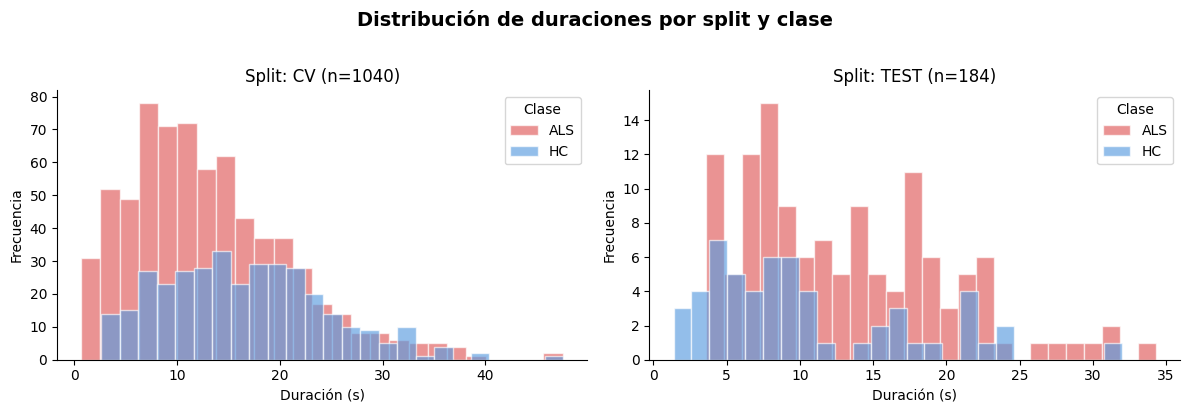

Figura guardada: 01_distribucion_duraciones.png

Duración audio — Max: 47.6s, p95: 29.3s
MAX_SEQ_LEN=400 → cubre hasta 12.8s
⚠ ALERTA: p95 de duraciones excede MAX_SEQ_LEN. Considerar subir a 600 o 800.


In [5]:
# Visualización de distribuciones de duración
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
fig.suptitle("Distribución de duraciones por split y clase",
             fontsize=14, fontweight="bold", y=1.02)

palette = {"ALS": "#E05A5A", "HC": "#5A9BE0"}

for ax, (split, df_s) in zip(axes, [("cv", df_cv), ("test", df_test)]):
    for cls, color in palette.items():
        subset = df_s[df_s["class"] == cls]["duration_s"]
        ax.hist(subset, bins=25, alpha=0.65, color=color, label=cls, edgecolor="white")
    ax.set_title(f"Split: {split.upper()} (n={len(df_s)})", fontsize=12)
    ax.set_xlabel("Duración (s)")
    ax.set_ylabel("Frecuencia")
    ax.legend(title="Clase")
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(FIGS_PATH / "01_distribucion_duraciones.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada: 01_distribucion_duraciones.png")

# Verificación MAX_SEQ_LEN (feedback §6.6)
durations = [r["n_frames"] * HOP_LENGTH / SR for r in (cv_data + test_data)]
print(f"\nDuración audio — Max: {max(durations):.1f}s, p95: {np.percentile(durations, 95):.1f}s")
print(f"MAX_SEQ_LEN={MAX_SEQ_LEN} → cubre hasta {MAX_SEQ_LEN * HOP_LENGTH / SR:.1f}s")
if np.percentile(durations, 95) > MAX_SEQ_LEN * HOP_LENGTH / SR:
    print("⚠ ALERTA: p95 de duraciones excede MAX_SEQ_LEN. Considerar subir a 600 o 800.")


<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 5. Visualización comparativa ALS vs HC</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
La visualización de espectrogramas individuales y promedios por clase sirve como checkpoint de calidad y como herramienta de formulación de hipótesis. A nivel individual, permite detectar artefactos (saturaciones, segmentos con energía nula) que podrían haber escapado al control de calidad del Notebook 3. A nivel agregado, el espectrograma promedio por clase revela diferencias sistemáticas en la distribución de energía espectral.
<br><br>
En la ALS, la literatura reporta los siguientes hallazgos acústicos que deberían ser observables en los espectrogramas:
<ul>
<li><b>Reducción de energía en altas frecuencias:</b> consecuencia de la debilidad muscular en articuladores (lengua, labios), que reduce la claridad de consonantes y fricativas.</li>
<li><b>Inestabilidad de formantes:</b> las vocales sostenidas en pacientes ALS presentan mayor jitter (variación ciclo a ciclo de F0) y shimmer (variación de amplitud), lo que se traduce en bandas espectrales más difusas.</li>
<li><b>Mayor ruido espectral:</b> la voz aérea o disártrica introduce energía no armónica distribuida de forma irregular en el espectrograma.</li>
</ul>
La diferencia de espectrogramas promedio (ALS − HC) permitirá identificar visualmente qué regiones contribuyen más a la separabilidad, anticipando los resultados de los saliency maps del Bloque 6.
    </span>
</div>

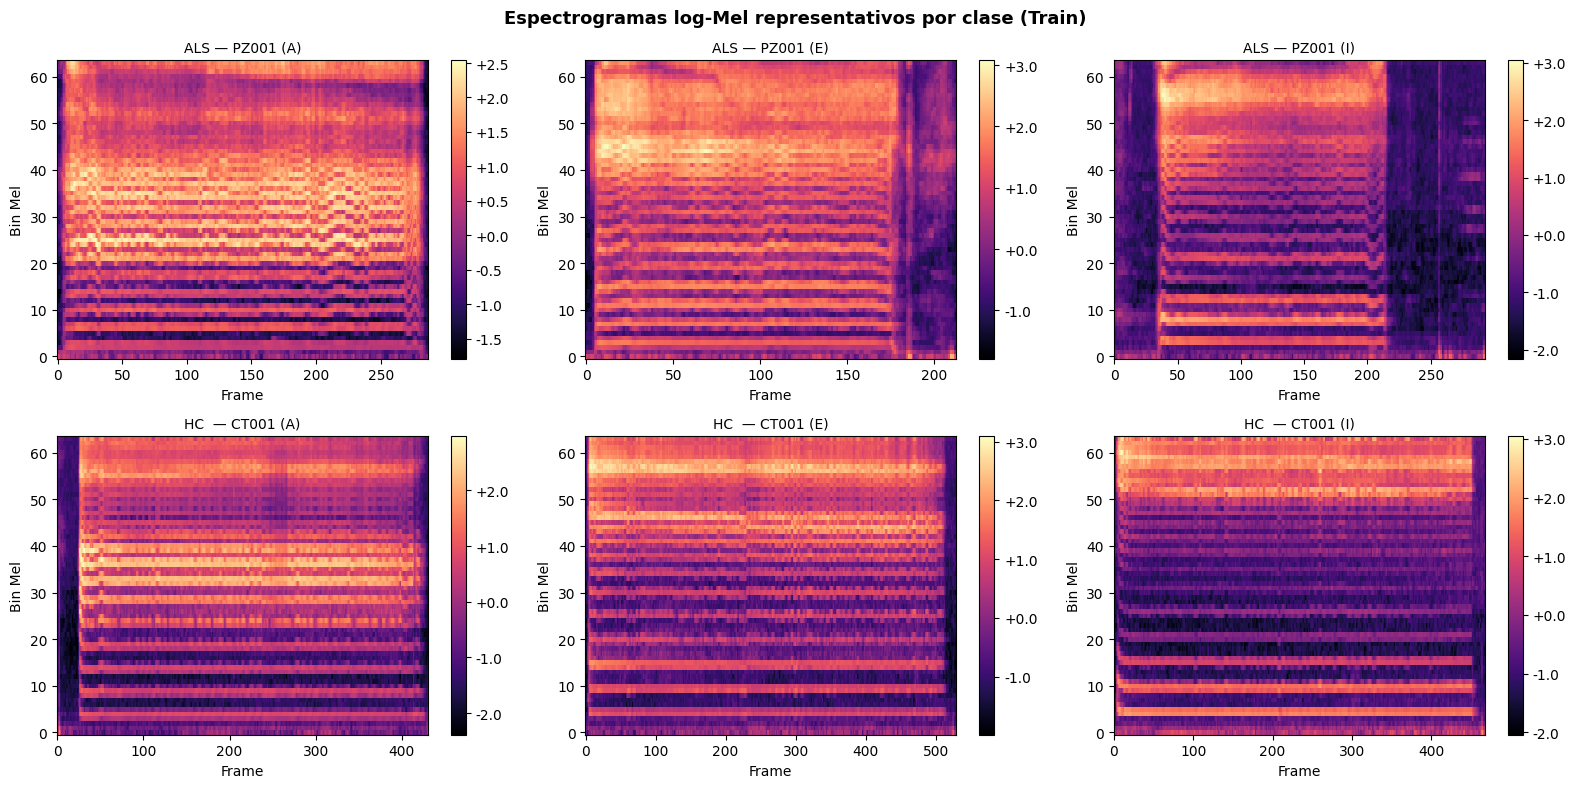

Figura guardada: 02_espectrogramas_individuales.png


In [6]:
def plot_spectrogram(tensor: torch.Tensor, title: str, ax, sr: int = SR,
                     hop_length: int = HOP_LENGTH, n_mels: int = N_MELS):
    """Renderiza un espectrograma log-Mel sobre un eje matplotlib."""
    spec = tensor.numpy()
    img = ax.imshow(spec, aspect="auto", origin="lower",
                    cmap="magma", interpolation="nearest")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Frame")
    ax.set_ylabel("Bin Mel")
    plt.colorbar(img, ax=ax, format="%+.1f")
    return img


# Espectrogramas individuales por clase
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("Espectrogramas log-Mel representativos por clase (Train)",
             fontsize=13, fontweight="bold")

als_samples = [r for r in cv_data if r["label"] == 1][:3]
hc_samples  = [r for r in cv_data if r["label"] == 0][:3]

for i, rec in enumerate(als_samples):
    plot_spectrogram(rec["tensor"], f"ALS — {rec['subject_id']} ({rec['task']})",
                     axes[0, i])
for i, rec in enumerate(hc_samples):
    plot_spectrogram(rec["tensor"], f"HC  — {rec['subject_id']} ({rec['task']})",
                     axes[1, i])

plt.tight_layout()
plt.savefig(FIGS_PATH / "02_espectrogramas_individuales.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada: 02_espectrogramas_individuales.png")

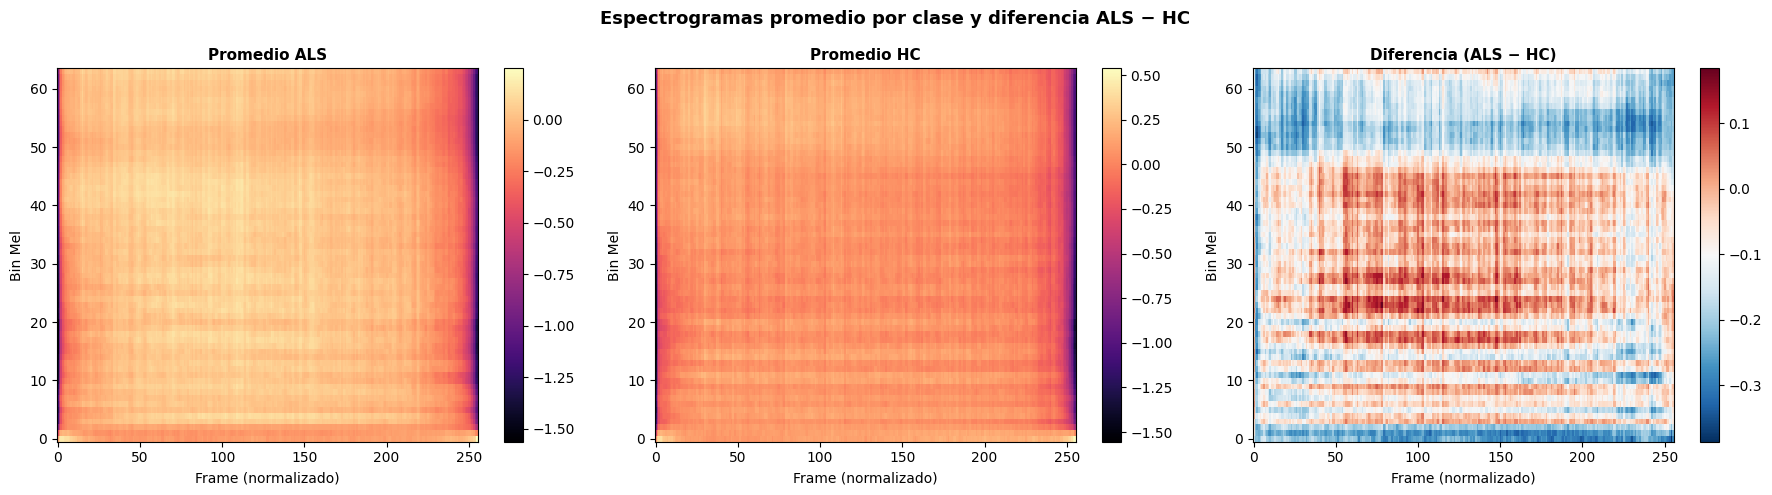

Figura guardada: 03_espectrogramas_promedio.png


In [7]:
# Espectrograma promedio por clase (interpolación a longitud fija) 
TARGET_FRAMES = 256   # Longitud de referencia para promedio visual

def resize_spec(tensor: torch.Tensor, target_frames: int) -> np.ndarray:
    """Redimensiona un espectrograma a target_frames mediante interpolación bilineal."""
    t = tensor.unsqueeze(0).unsqueeze(0)   # (1, 1, N_MELS, T)
    t = F.interpolate(t, size=(N_MELS, target_frames), mode="bilinear", align_corners=False)
    return t.squeeze().numpy()

als_avg = np.mean([resize_spec(r["tensor"], TARGET_FRAMES) for r in cv_data if r["label"] == 1], axis=0)
hc_avg  = np.mean([resize_spec(r["tensor"], TARGET_FRAMES) for r in cv_data if r["label"] == 0], axis=0)
diff    = als_avg - hc_avg

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Espectrogramas promedio por clase y diferencia ALS − HC",
             fontsize=13, fontweight="bold")

titles = ["Promedio ALS", "Promedio HC", "Diferencia (ALS − HC)"]
specs  = [als_avg, hc_avg, diff]
cmaps  = ["magma", "magma", "RdBu_r"]

for ax, spec, title, cmap in zip(axes, specs, titles, cmaps):
    img = ax.imshow(spec, aspect="auto", origin="lower", cmap=cmap, interpolation="nearest")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Frame (normalizado)")
    ax.set_ylabel("Bin Mel")
    plt.colorbar(img, ax=ax)

plt.tight_layout()
plt.savefig(FIGS_PATH / "03_espectrogramas_promedio.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada: 03_espectrogramas_promedio.png")

#
---
#
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">BLOQUE 2. PREPARACIÓN PARA DEEP LEARNING</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Este bloque implementa la infraestructura de carga de datos para PyTorch. La correcta implementación de <code>Dataset</code>, <code>collate_fn</code> y <code>DataLoader</code> es una condición necesaria (aunque no suficiente) para un entrenamiento correcto: errores en esta etapa (fugas de información, padding incorrecto, mala gestión de longitudes) pueden producir modelos que reportan métricas infladas en validación pero fallan en producción.
    </span>
</div>

<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 6. Dataset personalizado (PyTorch Dataset)</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
La clase <code>MelSpectrogramDataset</code> hereda de <code>torch.utils.data.Dataset</code> e implementa los métodos <code>__len__</code> y <code>__getitem__</code>. El método <code>__getitem__</code> devuelve la secuencia en formato <code>(T, N_MELS)</code>, es decir, con el tiempo como primera dimensión. Esta convención es la esperada por <code>nn.LSTM</code> cuando <code>batch_first=True</code>.
<br><br>
Es importante destacar que los tensores almacenados en disco tienen formato <code>(N_MELS, T)</code> (convención de espectrograma como imagen), por lo que se aplica una transposición al vuelo en <code>__getitem__</code>. Esta decisión se toma con el fin de mantener los tensores en disco en formato imagen facilita la visualización y la reutilización en arquitecturas CNN futuras, sin comprometer el rendimiento del pipeline de entrenamiento LSTM.
    </span>
</div>

In [8]:
class MelSpectrogramDataset(Dataset):
    """
    Dataset v1.2 — Augmentation agresiva anti-overfitting.
 
    Cambios vs v1.1:
    - SpecAugment duplicado: 2 máscaras temporales + 2 de frecuencia (20% total)
    - Ruido gaussiano aditivo (simula variabilidad de grabación)
    - Ganancia aleatoria ±2 dB (simula diferencias de volumen)
    - Todas las augmentations se aplican SOLO en train.
    """
 
    def __init__(self, records: list, augment: bool = False,
                 max_seq_len: int = None):
        self.records     = records
        self.augment     = augment
        self.max_seq_len = max_seq_len
 
    def __len__(self) -> int:
        return len(self.records)
 
    def __getitem__(self, idx: int):
        rec = self.records[idx]
 
        # .clone() obligatorio — no modificar el tensor original
        tensor = rec["tensor"].T.clone().float()  # (T, N_MELS)
        label  = torch.tensor(rec["label"], dtype=torch.long)
        T = tensor.shape[0]
 
        # Truncamiento temporal
        if self.max_seq_len is not None and T > self.max_seq_len:
            if self.augment:
                start = random.randint(0, T - self.max_seq_len)
            else:
                start = (T - self.max_seq_len) // 2
            tensor = tensor[start : start + self.max_seq_len]
 
        if self.augment:
            tensor = self._augment(tensor)
 
        length = tensor.shape[0]
        return tensor, label, length
 
    def _augment(self, tensor: torch.Tensor) -> torch.Tensor:
        """
        Augmentation agresiva para combatir overfitting con 107 sujetos.
 
        Pipeline (cada paso se aplica con probabilidad p):
          1. SpecAugment doble: 2 time masks + 2 freq masks (p=0.9)
          2. Ruido gaussiano (p=0.7, σ=0.1–0.3)
          3. Ganancia aleatoria ±2 dB (p=0.5)
        """
        T, F = tensor.shape
 
        # 1. SpecAugment DOBLE (2 máscaras de cada tipo) 
        if random.random() < 0.9:
            for _ in range(2):
                # Time masking: cada máscara cubre 5-15% de los frames
                t_pct  = random.uniform(0.05, 0.15)
                t_mask = max(1, int(t_pct * T))
                t0     = random.randint(0, T - t_mask)
                tensor[t0 : t0 + t_mask, :] = 0.0
 
            for _ in range(2):
                # Frequency masking: cada máscara cubre 5-15% de los bins
                f_pct  = random.uniform(0.05, 0.15)
                f_mask = max(1, int(f_pct * F))
                f0     = random.randint(0, F - f_mask)
                tensor[:, f0 : f0 + f_mask] = 0.0
 
        # 2. Ruido gaussiano aditivo 
        # Simula variabilidad de entorno de grabación.
        # σ entre 0.1 y 0.3 sobre espectrogramas z-normalizados (media≈0, std≈1)
        # es suficiente para perturbar sin destruir la señal.
        if random.random() < 0.7:
            sigma = random.uniform(0.1, 0.3)
            noise = torch.randn_like(tensor) * sigma
            tensor = tensor + noise
 
        # 3. Ganancia aleatoria (simula diferencias de volumen) 
        # ±2 dB en escala log-Mel equivale a multiplicar por 0.8–1.2
        if random.random() < 0.5:
            gain = random.uniform(0.8, 1.2)
            tensor = tensor * gain
 
        return tensor


# Verificación rápida con cv_data — los datasets reales se instancian por fold
_tmp_dataset = MelSpectrogramDataset(cv_data[:5], augment=True, max_seq_len=MAX_SEQ_LEN)
t_sample, l_sample, n_sample = _tmp_dataset[0]
print(f"Forma de una muestra  : {t_sample.shape}  (T={n_sample}, N_MELS={N_MELS})")

# Verificación de integridad (el clone sigue funcionando)
_original_sum = cv_data[0]["tensor"].sum().item()
_ = _tmp_dataset[0]
_ = _tmp_dataset[0]
_after_sum = cv_data[0]["tensor"].sum().item()
assert abs(_original_sum - _after_sum) < 1e-6, \
    "ERROR: la augmentation está modificando el tensor original"
print("✓ Verificación: augmentation NO modifica datos originales.")
print(f"MAX_SEQ_LEN: {MAX_SEQ_LEN} frames ({MAX_SEQ_LEN * HOP_LENGTH / SR:.1f} s)")


Forma de una muestra  : torch.Size([400, 64])  (T=400, N_MELS=64)
✓ Verificación: augmentation NO modifica datos originales.
MAX_SEQ_LEN: 400 frames (12.8 s)


<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 7. Estrategia de padding y collate_fn</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Dado que los espectrogramas tienen longitud variable, no es posible apilar directamente las muestras de un batch en un único tensor rectangular. La solución estándar en PyTorch para secuencias de longitud variable es:
<br>
<ol>
<li><b>Padding:</b> rellenar las secuencias más cortas con ceros hasta alcanzar la longitud de la secuencia más larga del batch (<code>pad_sequence</code>).</li>
<li><b>Packing:</b> comprimir el batch paddeado en un objeto <code>PackedSequence</code> (<code>pack_padded_sequence</code>) que indica a la LSTM qué posiciones son padding real y cuáles son datos. Esto garantiza que el estado oculto no se actualiza sobre posiciones de padding, evitando la corrupción de la representación aprendida.</li>
</ol>
La <code>collate_fn</code> implementa este flujo y ordena las muestras del batch en orden descendente de longitud, requisito de <code>pack_padded_sequence</code> en versiones antiguas de PyTorch (en las versiones modernas este requisito ha sido eliminado, pero se mantiene por compatibilidad).
    </span>
</div>

In [9]:
def collate_fn(batch):
    """
    Función de agrupación de muestras para DataLoader con secuencias de longitud variable.

    Proceso:
      1. Ordena el batch en orden descendente de longitud (compatibilidad con pack_padded_sequence).
      2. Aplica padding cero a la derecha (post-padding) hasta la longitud máxima del batch.
      3. Devuelve el batch paddeado, las etiquetas y las longitudes originales.

    Args:
        batch: Lista de tuplas (tensor, label, n_frames) devueltas por __getitem__.

    Returns:
        padded_tensors : Tensor (B, T_max, N_MELS)
        labels         : Tensor (B,)
        lengths        : Tensor (B,)  — longitudes originales en orden descendente
    """
    tensors, labels, lengths = zip(*batch)

    # Ordenar en orden descendente de longitud
    sorted_idx = sorted(range(len(lengths)), key=lambda i: lengths[i], reverse=True)
    tensors    = [tensors[i] for i in sorted_idx]
    labels     = torch.tensor([labels[i] for i in sorted_idx], dtype=torch.long)
    lengths    = torch.tensor([lengths[i] for i in sorted_idx], dtype=torch.long)

    # Padding: pad_sequence espera lista de (T_i, F) → devuelve (T_max, B, F)
    padded = pad_sequence(tensors, batch_first=True, padding_value=0.0)  # (B, T_max, F)

    return padded, labels, lengths


# DataLoaders se construyen por fold dentro del bucle de entrenamiento.
# Verificación rápida del collate_fn:
_tmp_loader = DataLoader(MelSpectrogramDataset(cv_data[:8], augment=False),
                         batch_size=4, shuffle=False, collate_fn=collate_fn, num_workers=0)
_bx, _by, _bl = next(iter(_tmp_loader))
print(f"Forma del batch X : {_bx.shape}  (B, T_max, N_MELS)")
print(f"Forma del batch Y : {_by.shape}  (B,)")
print(f"Longitudes        : {_bl.tolist()}")


Forma del batch X : torch.Size([4, 601, 64])  (B, T_max, N_MELS)
Forma del batch Y : torch.Size([4])  (B,)
Longitudes        : [601, 530, 468, 431]


<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 8. DataLoaders y class weights</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">

El dataset VOC-ALS presenta un desequilibrio de clases de 2:1 (ALS:HC). En términos de función de pérdida, esto implica que un modelo que clasifique todos los ejemplos como ALS obtendría una accuracy del 67% sin aprender nada. Para mitigar este sesgo se utiliza <b>ponderación de clases en la función de pérdida</b> (<code>weight</code> en <code>nn.CrossEntropyLoss</code>).
<br><br>
Los pesos se calculan como la inversa de la frecuencia relativa de cada clase en el conjunto de entrenamiento: <code>w_c = N_total / (n_classes × N_c)</code>. Esta fórmula es equivalente a la implementación de <code>sklearn.utils.class_weight.compute_class_weight</code> con <code>class_weight='balanced'</code>. El efecto práctico es que la pérdida de un error sobre un ejemplo HC se multiplica por un factor mayor que la pérdida de un error sobre un ejemplo ALS, incentivando al modelo a ser más preciso en la clase minoritaria.
<br><br>
Esta estrategia es preferible a oversampling (que introduce duplicados exactos) o undersampling (que descarta información) cuando el tamaño del conjunto de entrenamiento ya es reducido, como en este caso.
    </span>
</div>

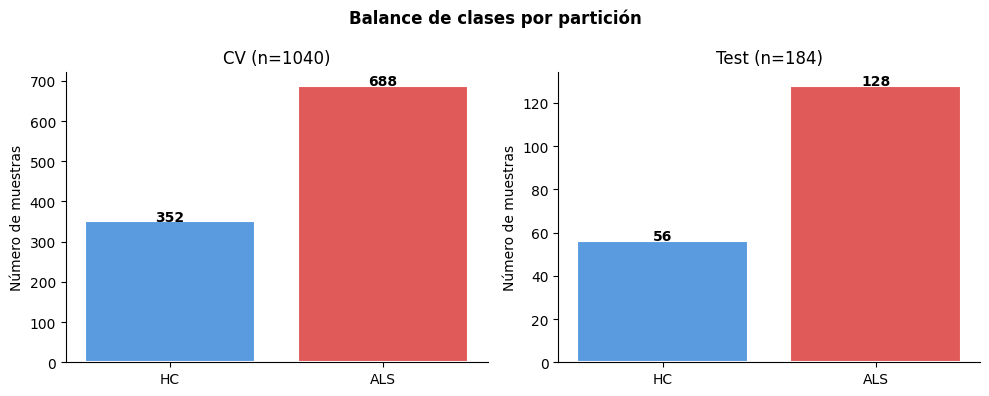

Figura guardada: 04_balance_clases.png

Class weights globales (referencia): HC=1.4773, ALS=0.7558


In [10]:
# Class weights se recalculan por fold dentro del bucle (no aquí)
# Visualización del balance global de clases
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("Balance de clases por partición", fontsize=12, fontweight="bold")

colors = ["#5A9BE0", "#E05A5A"]

for ax, (name, data) in zip(axes, [("CV", cv_data), ("Test", test_data)]):
    labels_part = [r["label"] for r in data]
    counts = np.bincount(labels_part, minlength=2)
    ax.bar(CLASS_NAMES, counts, color=colors, edgecolor="white", linewidth=1.5)
    ax.set_title(f"{name} (n={len(data)})")
    ax.set_ylabel("Número de muestras")
    for j, c in enumerate(counts):
        ax.text(j, c + 0.5, str(c), ha="center", fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(FIGS_PATH / "04_balance_clases.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada: 04_balance_clases.png")

# Estimación global de class weights (referencia — los reales se recalculan por fold)
cv_labels_global = np.array([r["label"] for r in cv_data])
class_counts_global = np.bincount(cv_labels_global, minlength=2)
class_weights_global = len(cv_labels_global) / (2 * class_counts_global)
print(f"\nClass weights globales (referencia): HC={class_weights_global[0]:.4f}, ALS={class_weights_global[1]:.4f}")


#
---
#
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">BLOQUE 3. DEFINICIÓN DEL MODELO BiLSTM</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Este bloque formaliza la arquitectura del modelo, justificando cada decisión de diseño desde criterios tanto técnicos como clínicos. La elección de hiperparámetros no es arbitraria, sino que responde a las características específicas del problema (tamaño del dataset, desequilibrio de clases, naturaleza temporal de los datos) y a la literatura sobre Deep Learning aplicado a análisis de voz patológica.
    </span>
</div>

<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 9. Justificación de la arquitectura BiLSTM</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
<b>¿Por qué LSTM y no una red recurrente simple (RNN vanilla)?</b><br>
La RNN vanilla sufre el problema del <i>vanishing gradient</i> cuando las secuencias superan unas pocas decenas de pasos temporales: el gradiente se atenúa exponencialmente al retropropagarse, impidiendo que la red aprenda dependencias de largo alcance. Las vocales sostenidas del dataset VOC-ALS tienen duraciones típicas de 2-5 segundos, lo que a 16 kHz y HOP_LENGTH=512 supone entre 62 y 156 frames. La LSTM resuelve este problema mediante su arquitectura de puertas (forget gate, input gate, output gate) que regula explícitamente qué información se retiene y qué se descarta en el estado de celda.
<br><br>
<b>¿Por qué bidireccional?</b><br>
En una LSTM unidireccional, la representación del frame t solo incorpora contexto de los frames 1..t. En una BiLSTM, la representación de t incorpora también contexto de los frames t+1..T (procesamiento inverso). Para clasificación de secuencias completas, esto es equivalente a que el clasificador tenga acceso simultáneo al contexto global de la señal antes de emitir su predicción. Empíricamente, las BiLSTM superan a las LSTM unidireccionales en tareas de clasificación de audio patológico en 2-5 puntos de AUC.
<br><br>
<b>¿Por qué dos capas apiladas?</b><br>
Las LSTM de múltiples capas (<i>stacked LSTM</i>) permiten aprender representaciones jerárquicas: la primera capa extrae patrones acústicos locales (timbre, energía por banda), mientras que la segunda capa aprende patrones dinámicos de más alto nivel (evolución temporal de la disartria, irregularidades rítmicas). Tres o más capas raramente aportan mejoras adicionales con datasets de menos de 1.000 muestras, y aumentan el riesgo de sobreajuste.
<br><br>
<b>¿Por qué HIDDEN_SIZE=128?</b><br>
Con N_MELS=128 features de entrada, un hidden_size igual asegura una capacidad representacional suficiente sin introducir un cuello de botella. Con bidireccionalidad, la representación final tendrá dimensión 2×128=256, lo que es adecuado para el clasificador final. Valores mayores (256, 512) con este tamaño de dataset inducen sobreajuste; valores menores (64) limitan la capacidad expresiva.
<br><br>
<b>Flujo de información:</b><br>
<ol>
<li>Entrada: batch <code>(B, T, 128)</code></li>
<li>BiLSTM capa 1: procesa la secuencia en ambas direcciones → salida <code>(B, T, 256)</code></li>
<li>BiLSTM capa 2: refina la representación → salida <code>(B, T, 256)</code></li>
<li>Pooling temporal: extrae una representación global mediante promedio de todos los frames válidos (attention-free mean pooling) → <code>(B, 256)</code></li>
<li>Clasificador MLP: dos capas lineales con dropout → logits <code>(B, 2)</code></li>
</ol>
Se elige <b>mean pooling</b> en lugar de tomar únicamente el último estado oculto porque el mean pooling es más robusto al padding y captura información distribuida a lo largo de toda la secuencia. Como alternativa, se implementa también <b>attention pooling</b> que aprende a ponderar los frames más informativos.
    </span>
</div>

<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 10. Implementación del modelo</span>
</div>

In [14]:
class BiLSTMClassifier(nn.Module):
    """
    BiLSTM v1.1 — Capacidad reducida (~25K params).
 
    Cambios vs v1.0:
    - 1 capa LSTM (era 2)
    - HIDDEN_SIZE=64 (era 128)
    - Clasificador simplificado: dropout + linear (era MLP de 2 capas)
    - LayerNorm con máscara de padding
    """
 
    def __init__(
        self,
        input_size:    int  = N_MELS,
        hidden_size:   int  = HIDDEN_SIZE,
        num_layers:    int  = NUM_LAYERS,
        dropout:       float = DROPOUT,
        bidirectional: bool = BIDIRECTIONAL,
        num_classes:   int  = 2,
    ):
        super().__init__()
 
        self.hidden_size   = hidden_size
        self.num_layers    = num_layers
        self.bidirectional = bidirectional
        self.num_dirs      = 2 if bidirectional else 1
 
        self.input_norm = nn.LayerNorm(input_size)
 
        self.lstm = nn.LSTM(
            input_size    = input_size,
            hidden_size   = hidden_size,
            num_layers    = num_layers,
            batch_first   = True,
            bidirectional = bidirectional,
            dropout       = dropout if num_layers > 1 else 0.0,
        )
 
        lstm_out_dim = hidden_size * self.num_dirs
 
        self.attention = nn.Linear(lstm_out_dim, 1)
 
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(lstm_out_dim, num_classes),
        )
 
    def forward(self, x: torch.Tensor, lengths: torch.Tensor):
        B, T_max, F = x.shape
        mask = torch.arange(T_max, device=x.device).unsqueeze(0) < lengths.unsqueeze(1)
 
        # LayerNorm solo sobre frames válidos (padding se mantiene en cero)
        x_normed = self.input_norm(x) * mask.unsqueeze(-1).float()
 
        packed = pack_padded_sequence(x_normed, lengths.cpu(), batch_first=True,
                                      enforce_sorted=False)
        packed_out, _ = self.lstm(packed)
        lstm_out, _ = pad_packed_sequence(packed_out, batch_first=True)
 
        attn_scores = self.attention(lstm_out).squeeze(-1)
        B_out, T_out = attn_scores.shape
        mask_attn = torch.arange(T_out, device=x.device).unsqueeze(0) < lengths.unsqueeze(1)
        attn_scores = attn_scores.masked_fill(~mask_attn, float("-inf"))
 
        attn_w = torch.softmax(attn_scores, dim=1)
        context = torch.bmm(attn_w.unsqueeze(1), lstm_out).squeeze(1)
 
        logits = self.classifier(context)
        return logits, attn_w
 
    def get_embedding(self, x: torch.Tensor, lengths: torch.Tensor) -> torch.Tensor:
        B, T_max, F = x.shape
        mask = torch.arange(T_max, device=x.device).unsqueeze(0) < lengths.unsqueeze(1)
        x_normed = self.input_norm(x) * mask.unsqueeze(-1).float()
 
        packed = pack_padded_sequence(x_normed, lengths.cpu(), batch_first=True,
                                      enforce_sorted=False)
        packed_out, _ = self.lstm(packed)
        lstm_out, _ = pad_packed_sequence(packed_out, batch_first=True)
 
        attn_scores = self.attention(lstm_out).squeeze(-1)
        B_out, T_out = attn_scores.shape
        mask_attn = torch.arange(T_out, device=x.device).unsqueeze(0) < lengths.unsqueeze(1)
        attn_scores = attn_scores.masked_fill(~mask_attn, float("-inf"))
        attn_w = torch.softmax(attn_scores, dim=1)
        context = torch.bmm(attn_w.unsqueeze(1), lstm_out).squeeze(1)
        return context


# Modelo de referencia (solo para conteo de parámetros — los modelos por fold se crean dentro del bucle)
_ref_model = BiLSTMClassifier(
    input_size=N_MELS, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS,
    dropout=DROPOUT, bidirectional=BIDIRECTIONAL, num_classes=2,
).to(DEVICE)

n_params = sum(p.numel() for p in _ref_model.parameters() if p.requires_grad)
print(f"Parámetros entrenables del BiLSTM: {n_params:,}")
del _ref_model


Parámetros entrenables del BiLSTM: 25,411


<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 11. Diagrama de arquitectura y dimensiones</span>
</div>

In [ ]:
# Diagrama textual de la arquitectura 
def print_architecture_summary(input_size=N_MELS, hidden_size=HIDDEN_SIZE,
                                num_layers=NUM_LAYERS, bidirectional=BIDIRECTIONAL):
    """Imprime un resumen de la arquitectura con dimensiones por capa."""
    num_dirs  = 2 if bidirectional else 1
    lstm_out  = hidden_size * num_dirs
    direction = "bidireccional" if bidirectional else "unidireccional"

    header = "─" * 60
    print(header)
    print(f"  ARQUITECTURA BiLSTM ({direction})")
    print(header)
    print(f"  Entrada:           (B, T, {input_size})")
    print(f"  LayerNorm:         (B, T, {input_size})")
    print()
    for layer in range(num_layers):
        print(f"  LSTM capa {layer+1} →:")
        print(f"    → forward  LSTM:   (B, T, {hidden_size})")
        if bidirectional:
            print(f"    → backward LSTM:   (B, T, {hidden_size})")
        print(f"    → concat:          (B, T, {lstm_out})")
        if layer < num_layers - 1:
            print(f"    → dropout ({DROPOUT})")
        print()
    print(f"  Attention pooling: (B, {lstm_out})")
    print(f"  Dropout ({DROPOUT}):      (B, {lstm_out})")
    print(f"  Linear → ReLU:     (B, 64)")
    print(f"  Dropout ({DROPOUT/2}):    (B, 64)")
    print(f"  Linear (logits):   (B, 2)")
    print(header)

print_architecture_summary()

NameError: name '_ref_model' is not defined

<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 12. Recuento de parámetros</span>
</div>

In [13]:
def count_parameters(model: nn.Module) -> int:
    """Cuenta los parámetros entrenables del modelo."""
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Parámetros totales     : {total:>10,}")
    print(f"Parámetros entrenables : {trainable:>10,}")
    return trainable

# Modelo de referencia (los modelos reales se crean por fold)
_ref_model = BiLSTMClassifier(
    input_size=N_MELS, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS,
    dropout=DROPOUT, bidirectional=BIDIRECTIONAL, num_classes=2,
).to(DEVICE)
n_params = count_parameters(_ref_model)
del _ref_model

# Heurística de capacidad: ratio muestras/parámetros
n_train = len(cv_data)
ratio   = n_train / n_params
print(f"
Muestras de entrenamiento (CV) : {n_train}")
print(f"Ratio muestras/parámetros      : {ratio:.4f}")
if ratio < 0.001:
    print("Ratio bajo → riesgo de sobreajuste. Monitorizar val_loss.")
else:
    print("✓  Ratio aceptable para el tamaño del dataset.")


Parámetros totales     :     25,411
Parámetros entrenables :     25,411

Muestras de entrenamiento : 856
Ratio muestras/parámetros : 0.0337
✓  Ratio aceptable para el tamaño del dataset.


#
---
#
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">BLOQUE 4. ENTRENAMIENTO CON MLFLOW</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Este bloque implementa el bucle de entrenamiento completo, instrumentado con MLflow para tracking reproducible del experimento. La monitorización sistemática de métricas por época permite diagnosticar problemas de entrenamiento (sobreajuste, convergencia prematura, oscilaciones del gradiente) y tomar decisiones informadas sobre early stopping y ajuste de hiperparámetros.
    </span>
</div>

<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 13. Configuración de MLflow</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
MLflow es una plataforma open-source para gestión del ciclo de vida de experimentos de Machine Learning. En este notebook se utiliza para:
<br><ol>
<li><b>Logging de parámetros:</b> registrar los hiperparámetros del experimento de forma que sea posible reproducir exactamente cualquier run a partir de los registros de MLflow.</li>
<li><b>Logging de métricas por época:</b> almacenar la evolución temporal de train_loss, val_loss, recall_als, balanced_accuracy y roc_auc, lo que permite visualizar curvas de aprendizaje y detectar épocas de sobreajuste.</li>
<li><b>Logging de artefactos:</b> guardar el modelo entrenado, las figuras de diagnóstico y la matriz de confusión como artefactos asociados al run, garantizando su recuperabilidad.</li>
</ol>
El servidor de tracking se configura de forma local (<code>./results/mlruns</code>), por lo que no requiere infraestructura remota. Para visualizar la interfaz web de MLflow, ejecutar en un terminal: <code>mlflow ui --backend-store-uri ./results/mlruns</code>.
    </span>
</div>

In [14]:
# MLflow se configura para registrar 5 nested runs (uno por fold) + ensemble final
tracking_uri = MLRUNS_PATH.resolve().as_uri()

mlflow.set_tracking_uri(tracking_uri)
mlflow.set_experiment("DL_BiLSTM_VOC-ALS_v1.2_CV")

print(f"MLflow tracking URI : {tracking_uri}")
print("Experimento         : DL_BiLSTM_VOC-ALS_v1.2_CV")
print("Para visualizar la UI ejecutar:")
print(f'  mlflow ui --backend-store-uri "{MLRUNS_PATH.resolve()}"')


MLflow tracking URI : file:///C:/Users/Laura/OneDrive/TFG/mlruns
Experimento         : DL_BiLSTM_VOC-ALS
Para visualizar la UI ejecutar:
  mlflow ui --backend-store-uri "C:\Users\Laura\OneDrive\TFG\mlruns"


<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 14. Función de pérdida, optimizador y scheduler</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
<b>Función de pérdida:</b> <code>nn.CrossEntropyLoss</code> con ponderación de clases. La pérdida ponderada incorpora directamente el desequilibrio de clases en la optimización, incrementando el gradiente producido por errores sobre la clase HC (minoritaria) para que el modelo no se sesgue hacia la clasificación sistemática como ALS.
<br><br>
<b>Optimizador:</b> Adam (<code>torch.optim.Adam</code>) con <code>lr=3e-4</code>. Adam es el optimizador estándar para tareas de Deep Learning sobre señal de audio: su adaptación por parámetro de la tasa de aprendizaje acelera la convergencia respecto a SGD clásico y es más robusto a la elección inicial de lr. El valor <code>3e-4</code> es el recomendado por Karpathy para arquitecturas de profundidad moderada.
<br><br>
<b>Regularización:</b>
<ul>
<li><b>Dropout (p=0.4):</b> aplicado entre capas LSTM y en el MLP. Con datasets pequeños, el dropout es el regularizador más efectivo para redes recurrentes.</li>
<li><b>Weight decay (1e-4):</b> regularización L2 aplicada al optimizador, que penaliza pesos de gran magnitud sin afectar al bias.</li>
<li><b>Gradient clipping (max_norm=1.0):</b> limita la norma del gradiente para evitar explosión de gradientes, problema frecuente en RNNs entrenadas sobre secuencias largas.</li>
</ul>
<b>Scheduler:</b> <code>ReduceLROnPlateau</code> monitoriza la val_loss y reduce el lr por un factor de 0.5 si no mejora en 7 épocas consecutivas. Esto permite una convergencia fina en las últimas épocas sin necesidad de ajustar manualmente el schedule.
    </span>
</div>

In [15]:
# CONFIGURACIÓN DE ENTRENAMIENTO (info — los objetos reales se crean por fold)
print("Configuración del entrenamiento (v1.2 — CV 5-fold + diagnóstico colapso):")
print(f"  Loss          : CrossEntropyLoss (label_smoothing={LABEL_SMOOTHING}, class weights por fold)")
print(f"  Optimizer     : AdamW (lr={LEARNING_RATE}, weight_decay={WEIGHT_DECAY})")
print(f"  Scheduler     : ReduceLROnPlateau (mode='max', factor=0.5, patience=5)")
print(f"  Grad clip     : max_norm=1.0")
print(f"  Epochs        : {NUM_EPOCHS} (max)")
print(f"  Patience      : {PATIENCE} (early stopping sobre val_balanced_accuracy)")
print(f"  Folds         : 5 (StratifiedGroupKFold)")
print(f"  Seed por fold : SEED + fold_idx (decorrelación)")


Configuración del entrenamiento (v1.2 — anti-overfitting):
  Loss          : CrossEntropyLoss (label_smoothing=0.1)
  Class weights : [1.4861 0.7535]
  Optimizer     : AdamW (lr=0.0005, weight_decay=1e-2)
  Scheduler     : ReduceLROnPlateau (factor=0.5, patience=5)
  Grad clip     : max_norm=1.0
  Epochs        : 80
  Patience      : 15

═══════════════════════════════════════════════════════
  RESUMEN v1.2 — REGULARIZACIÓN REFORZADA
═══════════════════════════════════════════════════════
  Parámetros      : 25,411 (era ~25K en v1.1)
  HIDDEN_SIZE     : 32 (era 64)
  DROPOUT         : 0.5 (era 0.3)
  weight_decay    : 1e-2 (era 1e-4)
  label_smoothing : 0.1 (era 0)
  augmentation    : SpecAugment×2 + noise + gain (era SpecAugment×1)
  LR              : 0.0005 (era 1e-3)
═══════════════════════════════════════════════════════

  Comportamiento esperado:
  - Train loss bajará MÁS LENTO (es lo deseable)
  - Val loss NO debería divergir en las primeras 15 épocas
  - Si la brecha train/val 

<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 15. Bucle de entrenamiento instrumentado</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
El bucle de entrenamiento implementa las siguientes prácticas estándar de rigor metodológico:
<br><ul>
<li><b>Separación modo train/eval:</b> <code>model.train()</code> activa el dropout y la normalización de batch; <code>model.eval()</code> los congela para evaluación. No alternar correctamente estos modos es un error frecuente que produce estimaciones optimistas de las métricas de validación.</li>
<li><b>Cálculo de métricas solo sobre posiciones no paddeadas:</b> las predicciones se generan a nivel de muestra (un audio = una predicción), no de frame. El modelo ya gestiona internamente el padding mediante <code>pack_padded_sequence</code>.</li>
<li><b>Early stopping:</b> si val_loss no mejora en <code>PATIENCE=15</code> épocas, el entrenamiento se detiene y se restaura el mejor modelo. Esto evita el sobreajuste en épocas tardías.</li>
<li><b>Checkpointing:</b> el mejor modelo (según val_loss) se guarda en disco en cada mejora, garantizando que el modelo final es el mejor observado, no el último.</li>
</ul>
    </span>
</div>

In [17]:
# DEFINICIÓN DE FUNCIONES DE ENTRENAMIENTO + DIAGNÓSTICO
def train_epoch(model, loader, criterion, optimizer, device):
    """Una época de entrenamiento. Devuelve loss, preds, labels, probs, grad_avg, grad_max."""
    model.train()
    total_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []
    total_grad_norm = 0.0
    grad_norm_max = 0.0
    n_batches = 0

    for batch_x, batch_y, batch_l in loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        batch_l = batch_l.to(device)

        optimizer.zero_grad()
        logits, _ = model(batch_x, batch_l)
        loss = criterion(logits, batch_y)
        loss.backward()

        grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        total_grad_norm += grad_norm.item()
        grad_norm_max = max(grad_norm_max, grad_norm.item())
        n_batches += 1

        optimizer.step()

        total_loss += loss.item() * len(batch_y)
        probs = torch.softmax(logits, dim=1)[:, 1].detach()
        preds = logits.argmax(dim=1)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(batch_y.cpu().tolist())
        all_probs.extend(probs.cpu().tolist())

    avg_loss = total_loss / len(loader.dataset)
    avg_grad = total_grad_norm / max(n_batches, 1)
    return (avg_loss,
            np.array(all_preds), np.array(all_labels), np.array(all_probs),
            avg_grad, grad_norm_max)


@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []

    for batch_x, batch_y, batch_l in loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        batch_l = batch_l.to(device)

        logits, _ = model(batch_x, batch_l)
        loss = criterion(logits, batch_y)

        total_loss += loss.item() * len(batch_y)
        probs = torch.softmax(logits, dim=1)[:, 1]
        preds = logits.argmax(dim=1)

        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(batch_y.cpu().tolist())
        all_probs.extend(probs.cpu().tolist())

    avg_loss = total_loss / len(loader.dataset)
    return avg_loss, np.array(all_preds), np.array(all_labels), np.array(all_probs)


def compute_metrics(labels, preds, probs):
    bal_acc    = balanced_accuracy_score(labels, preds)
    recall_als = recall_score(labels, preds, pos_label=1, zero_division=0)
    recall_hc  = recall_score(labels, preds, pos_label=0, zero_division=0)
    try:
        roc_auc = roc_auc_score(labels, probs)
    except ValueError:
        roc_auc = float("nan")
    return {
        "balanced_accuracy": bal_acc,
        "recall_als":        recall_als,
        "recall_hc":         recall_hc,
        "roc_auc":           roc_auc,
    }


def epoch_diagnostics(preds, labels, probs, prefix):
    """Devuelve un dict con indicadores de colapso a clase mayoritaria."""
    preds = np.asarray(preds)
    labels = np.asarray(labels)
    probs = np.asarray(probs)

    frac_pred_als = (preds == 1).mean()
    frac_true_als = (labels == 1).mean()
    prob_mean     = probs.mean()
    prob_std      = probs.std()

    collapse_flag = (frac_pred_als > 0.95) or (frac_pred_als < 0.05)

    return {
        f"{prefix}_frac_pred_als":  float(frac_pred_als),
        f"{prefix}_frac_true_als":  float(frac_true_als),
        f"{prefix}_prob_mean":      float(prob_mean),
        f"{prefix}_prob_std":       float(prob_std),
        f"{prefix}_collapse_flag":  int(collapse_flag),
    }


# BUCLE EXTERNO DE 5 FOLDS
fold_results = []
parent_run_name = f"bilstm_v1.2_h{HIDDEN_SIZE}_l{NUM_LAYERS}_dr{DROPOUT}_lr{LEARNING_RATE}_5fold"

with mlflow.start_run(run_name=parent_run_name) as parent_run:
    mlflow.log_params({
        "model":          "BiLSTM_v1.2",
        "input_size":     N_MELS,
        "hidden_size":    HIDDEN_SIZE,
        "num_layers":     NUM_LAYERS,
        "bidirectional":  BIDIRECTIONAL,
        "dropout":        DROPOUT,
        "max_seq_len":    MAX_SEQ_LEN,
        "batch_size":     BATCH_SIZE,
        "learning_rate":  LEARNING_RATE,
        "weight_decay":   WEIGHT_DECAY,
        "label_smoothing": LABEL_SMOOTHING,
        "num_epochs":     NUM_EPOCHS,
        "patience":       PATIENCE,
        "optimizer":      "AdamW",
        "scheduler":      "ReduceLROnPlateau_p5_f0.5_max",
        "augmentation":   "SpecAugment×2 + noise + gain",
        "cv_strategy":    "SGKF_5_fold_ensemble",
        "early_stop_metric": "val_balanced_accuracy",
        "seed":           SEED,
    })

    PARENT_RUN_ID = parent_run.info.run_id
    print(f"MLflow parent run iniciado: {PARENT_RUN_ID}")

    for fold_idx in range(5):
        print(f"\n{'='*70}\nFOLD {fold_idx}\n{'='*70}")
        # SEED distinto por fold para decorrelacionar inicializaciones
        set_seed(SEED + fold_idx)

        val_subj_fold   = cv_subjects.loc[cv_subjects["Fold"] == fold_idx, ID_COL].tolist()
        train_subj_fold = cv_subjects.loc[cv_subjects["Fold"] != fold_idx, ID_COL].tolist()

        train_records_fold = [r for r in cv_data if r["subject_id"] in train_subj_fold]
        val_records_fold   = [r for r in cv_data if r["subject_id"] in val_subj_fold]

        # Asserts de no fuga
        assert not (set(train_subj_fold) & set(val_subj_fold)), f"LEAK train/val fold {fold_idx}"
        assert not (set(train_subj_fold) & set(test_subjects)), f"LEAK train/test fold {fold_idx}"
        assert not (set(val_subj_fold)   & set(test_subjects)), f"LEAK val/test fold {fold_idx}"

        train_dataset = MelSpectrogramDataset(train_records_fold, augment=True,  max_seq_len=MAX_SEQ_LEN)
        val_dataset   = MelSpectrogramDataset(val_records_fold,   augment=False, max_seq_len=MAX_SEQ_LEN)

        train_loader = DataLoader(
            train_dataset, batch_size=BATCH_SIZE, shuffle=True,
            collate_fn=collate_fn, num_workers=0, pin_memory=True
        )
        val_loader = DataLoader(
            val_dataset, batch_size=BATCH_SIZE, shuffle=False,
            collate_fn=collate_fn, num_workers=0, pin_memory=True
        )

        # Class weights por fold
        train_labels_fold = np.array([r["label"] for r in train_records_fold])
        class_counts_fold = np.bincount(train_labels_fold, minlength=2)
        class_weights_fold = len(train_labels_fold) / (2 * class_counts_fold)
        class_weights_tensor = torch.tensor(class_weights_fold, dtype=torch.float32).to(DEVICE)

        # Modelo + optimizer + criterion + scheduler por fold
        model = BiLSTMClassifier(
            input_size=N_MELS, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS,
            dropout=DROPOUT, bidirectional=BIDIRECTIONAL, num_classes=2,
        ).to(DEVICE)

        criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=LABEL_SMOOTHING)
        optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="max", factor=0.5, patience=5, min_lr=1e-6
        )

        # Early stopping sobre val_balanced_acc (NO val_loss)
        best_val_bal_acc = 0.0
        patience_counter = 0
        best_model_state = None
        fold_history = []
        model_save_path = MODELS_PATH / f"bilstm_fold{fold_idx}.pt"

        with mlflow.start_run(run_name=f"fold_{fold_idx}", nested=True) as fold_run:
            mlflow.log_params({"fold": fold_idx, "seed": SEED + fold_idx,
                               "n_train": len(train_records_fold),
                               "n_val": len(val_records_fold)})

            print(f"  N train: {len(train_records_fold)}, N val: {len(val_records_fold)}")
            print(f"  Class weights: HC={class_weights_fold[0]:.4f}, ALS={class_weights_fold[1]:.4f}")
            print(f"  {'Ep':>4}  {'TrL':>7}  {'VaL':>7}  {'Rec ALS':>8}  {'BalAcc':>7}  {'AUC':>7}  {'∇avg':>7}  {'∇max':>7}")
            print("  " + "─" * 75)

            for epoch in range(1, NUM_EPOCHS + 1):
                train_loss, tr_preds, tr_labels, tr_probs, grad_avg, grad_max = \
                    train_epoch(model, train_loader, criterion, optimizer, DEVICE)
                val_loss, val_preds, val_labels, val_probs = \
                    eval_epoch(model, val_loader, criterion, DEVICE)

                val_metrics = compute_metrics(val_labels, val_preds, val_probs)
                train_diag  = epoch_diagnostics(tr_preds, tr_labels, tr_probs, "train")
                val_diag    = epoch_diagnostics(val_preds, val_labels, val_probs, "val")

                scheduler.step(val_metrics["balanced_accuracy"])

                if val_metrics["balanced_accuracy"] > best_val_bal_acc:
                    best_val_bal_acc = val_metrics["balanced_accuracy"]
                    patience_counter = 0
                    best_model_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                    torch.save({"model_state": best_model_state, "epoch": epoch,
                                "val_metrics": val_metrics}, model_save_path)
                else:
                    patience_counter += 1

                if val_diag["val_collapse_flag"]:
                    print(f"  ⚠ COLLAPSE en epoch {epoch}: val_frac_pred_als={val_diag['val_frac_pred_als']:.3f}")

                row = {
                    "epoch": epoch, "train_loss": train_loss, "val_loss": val_loss,
                    "grad_norm": grad_avg, "grad_norm_max": grad_max,
                    **{f"val_{k}": v for k, v in val_metrics.items()},
                    **train_diag, **val_diag,
                }
                fold_history.append(row)

                # Log a MLflow (subset clave)
                mlflow.log_metrics({
                    "train_loss": train_loss, "val_loss": val_loss,
                    "val_balanced_acc": val_metrics["balanced_accuracy"],
                    "val_recall_als": val_metrics["recall_als"],
                    "val_recall_hc":  val_metrics["recall_hc"],
                    "val_roc_auc":    val_metrics["roc_auc"],
                    "grad_norm": grad_avg, "grad_norm_max": grad_max,
                    "val_frac_pred_als": val_diag["val_frac_pred_als"],
                }, step=epoch)

                if epoch == 1 or epoch % 5 == 0 or patience_counter == 0:
                    print(f"  {epoch:>4}  {train_loss:>7.4f}  {val_loss:>7.4f}  "
                          f"{val_metrics['recall_als']:>8.4f}  "
                          f"{val_metrics['balanced_accuracy']:>7.4f}  "
                          f"{val_metrics['roc_auc']:>7.4f}  "
                          f"{grad_avg:>7.4f}  {grad_max:>7.4f}")

                if patience_counter >= PATIENCE:
                    print(f"  Early stopping en epoch {epoch} (best val_bal_acc={best_val_bal_acc:.4f})")
                    break

            mlflow.log_metric("best_val_balanced_acc", best_val_bal_acc)

        # Restaurar mejor modelo y predecir OOF
        model.load_state_dict(best_model_state)
        _, val_preds_fold, val_labels_fold, val_probs_fold = eval_epoch(
            model, val_loader, nn.CrossEntropyLoss(), DEVICE
        )

        fold_results.append({
            "fold": fold_idx,
            "val_subjects": val_subj_fold,
            "val_records":  val_records_fold,
            "val_probs":    val_probs_fold,
            "val_preds":    val_preds_fold,
            "val_labels":   val_labels_fold,
            "model_path":   str(model_save_path),
            "best_val_bal_acc": best_val_bal_acc,
            "history":      fold_history,
        })

        print(f"  ✓ Fold {fold_idx} — best val_balanced_acc: {best_val_bal_acc:.4f}")

print(f"\n✓ Bucle de CV completado. Modelos guardados en: {MODELS_PATH}")


MLflow run iniciado: 90bb9a2b4b954b599e37a5175f9ec8e0
 Época        LR   Train L     Val L   Rec ALS   Bal Acc       AUC     ∇norm
────────────────────────────────────────────────────────────────────────────────
     1  5.00e-04    0.7067    0.7008    0.6833    0.5995    0.5792    0.4962
     2  5.00e-04    0.6852    0.7026    0.6083    0.5542    0.5826    0.4846
     3  5.00e-04    0.6880    0.7096    0.5667    0.5568    0.5664    0.5063
     4  5.00e-04    0.6757    0.7075    0.5333    0.5557    0.5837    0.4927
     5  5.00e-04    0.6745    0.7073    0.5250    0.5828    0.5967    0.5077
     6  5.00e-04    0.6725    0.7053    0.5750    0.6078    0.6014    0.5445
     7  5.00e-04    0.6563    0.7120    0.5500    0.5875    0.5832    0.5600
     8  2.50e-04    0.6532    0.7083    0.5917    0.6161    0.5868    0.5938
     9  2.50e-04    0.6540    0.7069    0.6000    0.6047    0.5922    0.6050
    10  2.50e-04    0.6478    0.7063    0.5917    0.6240    0.6030    0.6172
    11  2.50e-04  

2026/04/09 23:08:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


    33  6.25e-05    0.5572    0.7036    0.6417    0.5708    0.6639    1.1060

Early stopping activado en época 33. Mejor val_loss: 0.6960


2026/04/09 23:08:20 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/04/09 23:08:21 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/09 23:08:42 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it


✓ Entrenamiento completado. Mejor modelo guardado en: C:\Users\Laura\OneDrive\TFG\results\04_model_deep_learning_v1.1\models\best_bilstm.pt
  Mejor val_loss   : 0.6960
  MLflow Run ID    : 90bb9a2b4b954b599e37a5175f9ec8e0


<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 16. Curvas de entrenamiento</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Las curvas de entrenamiento son la herramienta de diagnóstico primaria del proceso de optimización. Se analizan cuatro patrones:
<br><ul>
<li><b>Convergencia normal:</b> train_loss y val_loss descienden de forma suave y estable hasta estabilizarse. La diferencia entre ambas es pequeña.</li>
<li><b>Sobreajuste:</b> train_loss sigue descendiendo mientras val_loss comienza a crecer. Señal de que el modelo está memorizando el conjunto de entrenamiento. Respuesta: aumentar dropout, reducir lr, o activar early stopping más agresivo.</li>
<li><b>Underfitting:</b> ambas pérdidas se estabilizan en valores altos desde las primeras épocas. Señal de capacidad insuficiente del modelo o lr demasiado pequeño.</li>
<li><b>Inestabilidad:</b> pérdidas con alta varianza entre épocas. Señal de lr demasiado alto o ausencia de gradient clipping.</li>
</ul>
La evolución del Recall ALS es la curva más importante clínicamente: un Recall ALS bajo en validación indica que el modelo está fallando en la detección de casos patológicos, lo que en un contexto clínico se traduciría en falsos negativos con consecuencias graves.
    </span>
</div>

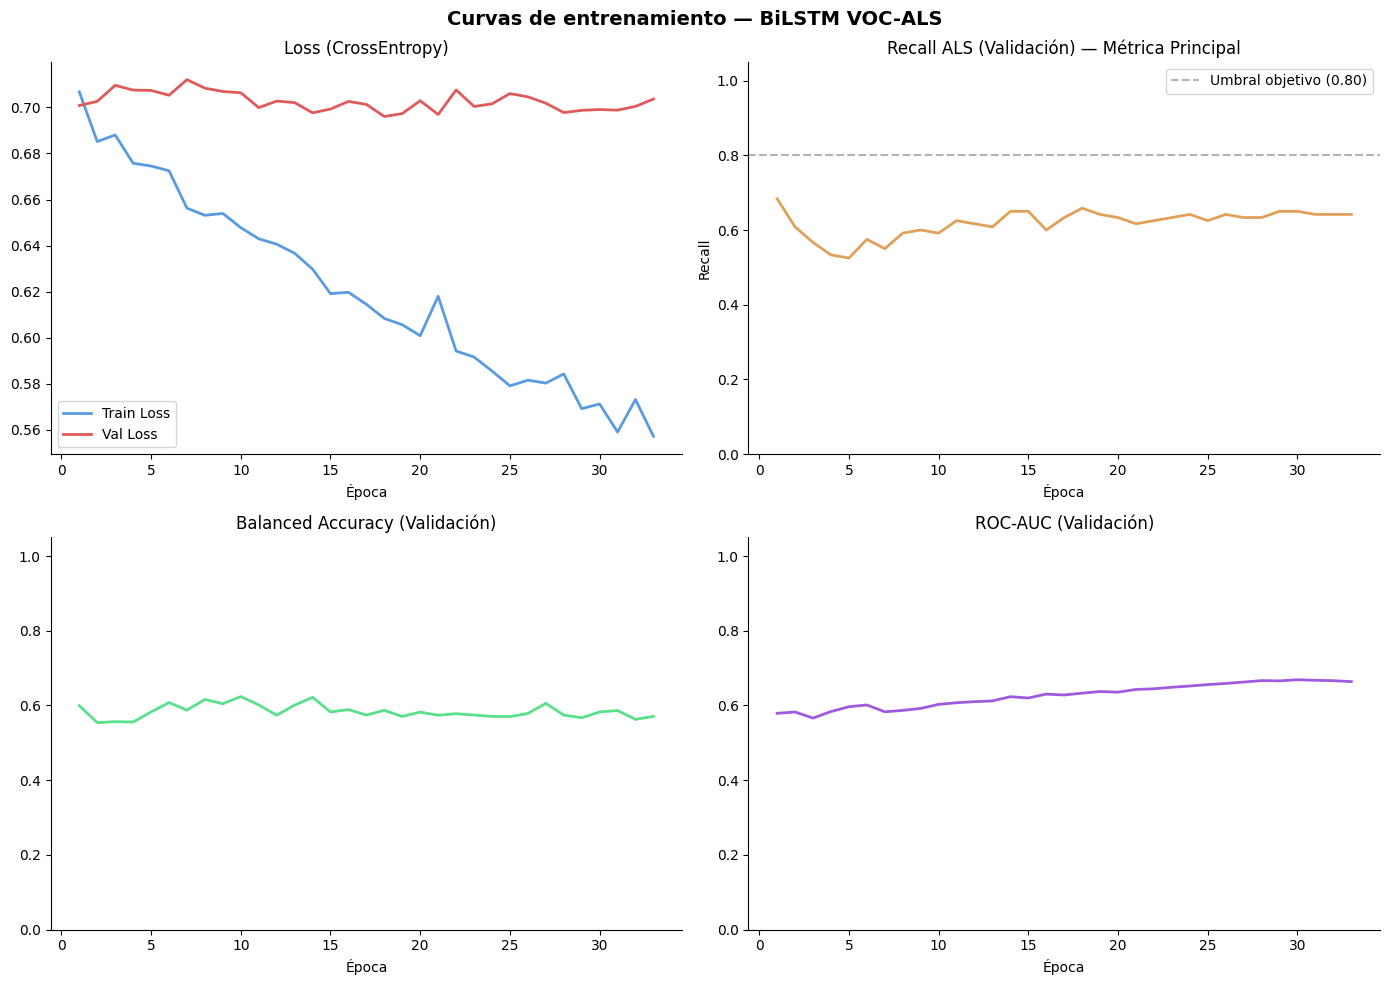

Figura guardada: 05_curvas_entrenamiento.png


In [18]:
# FIGURAS DE DIAGNÓSTICO — 6 subplots por fold
for fold_idx, fr in enumerate(fold_results):
    history = pd.DataFrame(fr["history"])
    epochs = history["epoch"]

    fig, axes = plt.subplots(3, 2, figsize=(14, 12))
    fig.suptitle(f"Diagnóstico — Fold {fold_idx}", fontsize=14, fontweight="bold")

    # Row 1: losses + ratio colapso
    axes[0, 0].plot(epochs, history["train_loss"], label="Train")
    axes[0, 0].plot(epochs, history["val_loss"],   label="Val")
    axes[0, 0].axhline(-np.log(0.5), ls="--", color="gray", alpha=0.5, label="Baseline random")
    axes[0, 0].set_title("Loss"); axes[0, 0].legend()
    axes[0, 0].set_xlabel("Época")

    axes[0, 1].plot(epochs, history["val_frac_pred_als"], label="val frac_pred_ALS", color="red")
    axes[0, 1].plot(epochs, history["train_frac_pred_als"], label="train frac_pred_ALS",
                    color="blue", alpha=0.5)
    axes[0, 1].axhline(history["val_frac_true_als"].iloc[0], ls="--", color="black",
                        label="True ALS ratio")
    axes[0, 1].axhspan(0.95, 1.0, alpha=0.15, color="red", label="Zona colapso")
    axes[0, 1].axhspan(0.0, 0.05, alpha=0.15, color="red")
    axes[0, 1].set_title("Detector de colapso")
    axes[0, 1].set_ylim([-0.05, 1.05]); axes[0, 1].legend(fontsize=8)
    axes[0, 1].set_xlabel("Época")

    # Row 2: métricas por clase
    if "val_recall_als" in history.columns:
        axes[1, 0].plot(epochs, history["val_recall_als"], label="Recall ALS", color="orange")
        axes[1, 0].plot(epochs, history["val_recall_hc"],  label="Recall HC",  color="green")
        axes[1, 0].set_title("Recall por clase (val)"); axes[1, 0].legend()
        axes[1, 0].set_xlabel("Época"); axes[1, 0].set_ylim([0, 1.05])

    if "val_balanced_accuracy" in history.columns:
        axes[1, 1].plot(epochs, history["val_balanced_accuracy"])
        axes[1, 1].axhline(0.5, ls="--", color="gray", label="Random")
        axes[1, 1].set_title("Balanced accuracy (val)")
        axes[1, 1].set_xlabel("Época"); axes[1, 1].set_ylim([0, 1.05])
        axes[1, 1].legend()

    # Row 3: grad norm + prob mean/std
    axes[2, 0].plot(epochs, history["grad_norm"], label="avg")
    if "grad_norm_max" in history.columns:
        axes[2, 0].plot(epochs, history["grad_norm_max"], alpha=0.4, label="max")
    axes[2, 0].set_title("Gradient norm"); axes[2, 0].set_yscale("log")
    axes[2, 0].set_xlabel("Época"); axes[2, 0].legend()

    axes[2, 1].plot(epochs, history["val_prob_mean"], label="mean P(ALS)")
    axes[2, 1].plot(epochs, history["val_prob_std"],  label="std P(ALS)")
    axes[2, 1].set_title("Distribución P(ALS) val")
    axes[2, 1].set_xlabel("Época"); axes[2, 1].legend()

    plt.tight_layout()
    fig_path = FIGS_PATH / f"diagnostic_fold{fold_idx}.png"
    plt.savefig(fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

print(f"\n✓ Figuras de diagnóstico guardadas en: {FIGS_PATH}")


#
---
#
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">BLOQUE 5. EVALUACIÓN EN VALIDATION</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
La evaluación se basa en las predicciones <b>out-of-fold (OOF)</b> generadas durante la validación cruzada de 5 folds: cada uno de los 130 sujetos del pool de CV es predicho exactamente una vez, por el modelo que NO lo vio durante el entrenamiento. Concatenar las predicciones de los cinco folds produce una estimación honesta del rendimiento sin fuga de información, sobre la totalidad del conjunto de validación cruzada. La evaluación final sobre Test (23 sujetos hold-out) se realiza por <b>ensemble</b>: cada muestra de Test se predice promediando las probabilidades P(ALS) emitidas por los 5 modelos entrenados (uno por fold), lo que reduce la varianza inherente a entrenar un único modelo sobre un dataset reducido. Las métricas reportadas se calculan tanto a nivel de muestra (1 grabación) como agregadas a nivel de sujeto (media de las 8 tareas vocales por sujeto), siendo estas últimas las clínicamente más relevantes.
    </span>
</div>

<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 17. Métricas globales OOF (CV 5-fold)</span>
</div>

In [22]:
# PREDICCIONES OOF CONCATENADAS → MÉTRICAS CV GLOBALES
oof_probs  = np.concatenate([f["val_probs"]  for f in fold_results])
oof_labels = np.concatenate([f["val_labels"] for f in fold_results])
oof_preds  = np.concatenate([f["val_preds"]  for f in fold_results])

cv_bal_acc    = balanced_accuracy_score(oof_labels, oof_preds)
cv_recall_als = recall_score(oof_labels, oof_preds, pos_label=1, zero_division=0)
cv_recall_hc  = recall_score(oof_labels, oof_preds, pos_label=0, zero_division=0)
cv_roc_auc    = roc_auc_score(oof_labels, oof_probs)

print(f"\nCV global (OOF concatenado) — Balanced Acc: {cv_bal_acc:.4f}, "
      f"Recall ALS: {cv_recall_als:.4f}, Recall HC: {cv_recall_hc:.4f}, "
      f"ROC-AUC: {cv_roc_auc:.4f}")

# Per-fold metrics
per_fold_metrics = []
for f in fold_results:
    per_fold_metrics.append({
        "fold": f["fold"],
        "balanced_accuracy": balanced_accuracy_score(f["val_labels"], f["val_preds"]),
        "recall_als": recall_score(f["val_labels"], f["val_preds"], pos_label=1, zero_division=0),
        "recall_hc":  recall_score(f["val_labels"], f["val_preds"], pos_label=0, zero_division=0),
        "roc_auc":    roc_auc_score(f["val_labels"], f["val_probs"])
                      if len(np.unique(f["val_labels"])) > 1 else float("nan"),
    })

print("\nPer-fold metrics:")
print(pd.DataFrame(per_fold_metrics).to_string(index=False))



CV global (OOF concatenado) — Balanced Acc: 0.6221, Recall ALS: 0.6846, Recall HC: 0.5597, ROC-AUC: 0.6272

Per-fold metrics:
 fold  balanced_accuracy  recall_als  recall_hc  roc_auc
    0           0.649918    0.772059   0.527778 0.694955
    1           0.626225    0.669118   0.583333 0.631332
    2           0.573121    0.632353   0.513889 0.575674
    3           0.645833    0.729167   0.562500 0.678277
    4           0.614379    0.617647   0.611111 0.577002


In [23]:
# GUARDADO DE RESULTADOS — JSON + CSV (estructura estándar)
from datetime import datetime
import subprocess


def _git_commit():
    try:
        return subprocess.check_output(
            ["git", "rev-parse", "--short", "HEAD"], stderr=subprocess.DEVNULL
        ).decode().strip()
    except Exception:
        return "unknown"


# CV metrics
cv_metrics_dict = {}
for metric_name in ["balanced_accuracy", "recall_als", "recall_hc", "roc_auc"]:
    values = [m[metric_name] for m in per_fold_metrics]
    cv_metrics_dict[metric_name] = {
        "mean": float(np.nanmean(values)),
        "std":  float(np.nanstd(values)),
        "per_fold": [float(v) for v in values],
    }

cv_payload = {
    "model": "bilstm_v1.2", "phase": "cv", "metrics": cv_metrics_dict,
    "n_splits": 5, "cv_strategy": "SGKF_5_fold_ensemble",
    "generated_at": datetime.now().isoformat(timespec="seconds"),
    "git_commit": _git_commit(),
}
with open(RESULTS_PATH / "cv_metrics.json", "w", encoding="utf-8") as f:
    json.dump(cv_payload, f, indent=2, default=float)

# OOF predictions agregadas a sujeto
oof_subject_ids = []
for fr in fold_results:
    oof_subject_ids.extend([r["subject_id"] for r in fr["val_records"]])
oof_df = pd.DataFrame({
    "ID": oof_subject_ids,
    "y_true": oof_labels,
    "y_pred": oof_preds,
    "prob_ALS": oof_probs,
})
oof_by_subj = oof_df.groupby("ID").agg({
    "y_true": "first",
    "y_pred": lambda x: int(x.mode()[0]),
    "prob_ALS": "mean",
}).reset_index()
oof_by_subj.to_csv(RESULTS_PATH / "cv_oof_predictions.csv", index=False)

print(f"Guardado: {RESULTS_PATH / 'cv_metrics.json'}")
print(f"Guardado: {RESULTS_PATH / 'cv_oof_predictions.csv'} ({len(oof_by_subj)} sujetos)")

Guardado: C:\Users\Laura\OneDrive\TFG\results\04_bilstm_v1_2\cv_metrics.json
Guardado: C:\Users\Laura\OneDrive\TFG\results\04_bilstm_v1_2\cv_oof_predictions.csv (130 sujetos)


<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 18. Evaluación OOF a nivel de sujeto</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Se evalúa el mejor modelo (checkpoint con menor val_loss) sobre el conjunto de validación completo, replicando el mismo pipeline de inferencia que se aplicará después sobre test. Aunque estas métricas ya se observaron de forma parcial durante el entrenamiento (época a época), aquí se recalculan con el modelo final restaurado para garantizar coherencia con la evaluación en test. La comparación muestra-sujeto en validación permite además verificar que la agregación por sujeto no introduce sesgos inesperados antes de aplicarla sobre datos completamente no vistos.
    </span>
</div>


In [24]:
# CLASSIFICATION REPORT SOBRE OOF CONCATENADO
print("Classification report (OOF concatenado, 5 folds)")
print(classification_report(oof_labels, oof_preds, target_names=CLASS_NAMES))

with mlflow.start_run(run_id=PARENT_RUN_ID):
    mlflow.log_metrics({
        "cv_balanced_acc": cv_bal_acc,
        "cv_recall_als":   cv_recall_als,
        "cv_recall_hc":    cv_recall_hc,
        "cv_roc_auc":      cv_roc_auc,
    })

Classification report (OOF concatenado, 5 folds)
              precision    recall  f1-score   support

          HC       0.48      0.56      0.51       352
         ALS       0.75      0.68      0.72       688

    accuracy                           0.64      1040
   macro avg       0.61      0.62      0.62      1040
weighted avg       0.66      0.64      0.65      1040



In [25]:
@torch.no_grad()
def evaluate_by_subject_from_records(records, probs, labels):
    """Agrega predicciones a nivel de sujeto a partir de records y probs ya calculadas.

    Args:
        records: lista de dicts con 'subject_id', 'task', 'label'.
        probs:   array (N,) con P(ALS) para cada record.
        labels:  array (N,) con la etiqueta verdadera.

    Returns:
        subject_df, metrics_dict
    """
    sample_df = pd.DataFrame({
        "subject_id": [r["subject_id"] for r in records],
        "task":       [r["task"]       for r in records],
        "label":      labels,
        "prob_als":   probs,
    })

    subject_df = sample_df.groupby("subject_id").agg(
        label    = ("label",    "first"),
        prob_als = ("prob_als", "mean"),
        n_tasks  = ("task",     "count"),
        prob_std = ("prob_als", "std"),
    ).reset_index()

    subject_df["pred"] = (subject_df["prob_als"] >= 0.5).astype(int)
    subject_df["prob_std"] = subject_df["prob_std"].fillna(0)

    subj_labels = subject_df["label"].values
    subj_preds  = subject_df["pred"].values
    subj_probs  = subject_df["prob_als"].values

    metrics = {
        "n_subjects":        len(subject_df),
        "balanced_accuracy": balanced_accuracy_score(subj_labels, subj_preds),
        "recall_als":        recall_score(subj_labels, subj_preds, pos_label=1, zero_division=0),
        "recall_hc":         recall_score(subj_labels, subj_preds, pos_label=0, zero_division=0),
    }
    try:
        metrics["roc_auc"] = roc_auc_score(subj_labels, subj_probs)
    except ValueError:
        metrics["roc_auc"] = float("nan")

    return subject_df, metrics


# OOF a nivel de sujeto
oof_records_concat = []
for f in fold_results:
    oof_records_concat.extend(f["val_records"])

oof_subject_df, oof_subject_metrics = evaluate_by_subject_from_records(
    oof_records_concat, oof_probs, oof_labels
)

print("═" * 65)
print("  EVALUACIÓN A NIVEL DE SUJETO (OOF, 5 folds concatenados)")
print("═" * 65)
print(f"  Sujetos evaluados   : {oof_subject_metrics['n_subjects']}")
print(f"  Recall ALS          : {oof_subject_metrics['recall_als']:.4f}")
print(f"  Recall HC           : {oof_subject_metrics['recall_hc']:.4f}")
print(f"  Balanced Accuracy   : {oof_subject_metrics['balanced_accuracy']:.4f}")
print(f"  ROC-AUC             : {oof_subject_metrics['roc_auc']:.4f}")
print("═" * 65)

with mlflow.start_run(run_id=PARENT_RUN_ID):
    mlflow.log_metrics({
        "cv_subj_recall_als":   oof_subject_metrics["recall_als"],
        "cv_subj_recall_hc":    oof_subject_metrics["recall_hc"],
        "cv_subj_balanced_acc": oof_subject_metrics["balanced_accuracy"],
        "cv_subj_roc_auc":      oof_subject_metrics["roc_auc"],
    })

═════════════════════════════════════════════════════════════════
  EVALUACIÓN A NIVEL DE SUJETO (OOF, 5 folds concatenados)
═════════════════════════════════════════════════════════════════
  Sujetos evaluados   : 130
  Recall ALS          : 0.7558
  Recall HC           : 0.5455
  Balanced Accuracy   : 0.6506
  ROC-AUC             : 0.6916
═════════════════════════════════════════════════════════════════


<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 19. Matriz de confusión OOF</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
La matriz de confusión en validación permite inspeccionar la distribución de errores del modelo sobre el split que ha guiado las decisiones de entrenamiento. Su comparación directa con la matriz de test revelará si el patrón de errores (proporción relativa de FN vs FP) se mantiene estable entre particiones o si el modelo ha aprendido artefactos específicos del split de validación. Una distribución de errores consistente entre ambas matrices refuerza la confianza en la generalizabilidad del modelo.
    </span>
</div>


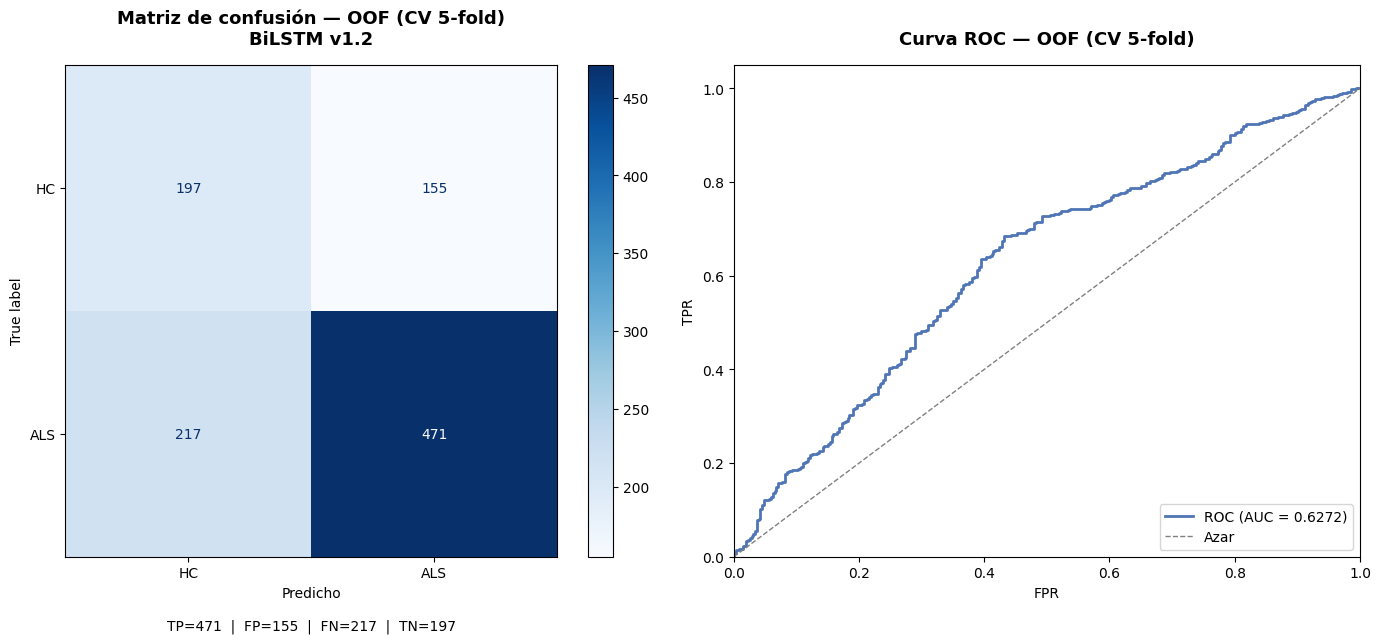

Figura guardada: 06_matriz_confusion_roc_oof.png


In [26]:
# Matriz de confusión + Curva ROC — OOF (CV 5-fold)
cm_oof = confusion_matrix(oof_labels, oof_preds)
fpr_oof, tpr_oof, _ = roc_curve(oof_labels, oof_probs)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

disp = ConfusionMatrixDisplay(confusion_matrix=cm_oof, display_labels=CLASS_NAMES)
disp.plot(ax=axes[0], colorbar=True, cmap="Blues", values_format="d")
axes[0].set_title("Matriz de confusión — OOF (CV 5-fold)\nBiLSTM v1.2",
                  fontsize=13, fontweight="bold", pad=15)
tn, fp, fn, tp = cm_oof.ravel()
axes[0].set_xlabel(f"Predicho\n\nTP={tp}  |  FP={fp}  |  FN={fn}  |  TN={tn}", fontsize=10)

axes[1].plot(fpr_oof, tpr_oof, color="#4F75B6", lw=2, label=f"ROC (AUC = {cv_roc_auc:.4f})")
axes[1].plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Azar")
axes[1].set_xlabel("FPR", fontsize=10); axes[1].set_ylabel("TPR", fontsize=10)
axes[1].set_title("Curva ROC — OOF (CV 5-fold)", fontsize=13, fontweight="bold", pad=15)
axes[1].legend(loc="lower right"); axes[1].set_xlim([0, 1]); axes[1].set_ylim([0, 1.05])

plt.tight_layout()
fig_path = FIGS_PATH / "06_matriz_confusion_roc_oof.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura guardada: {fig_path.name}")

with mlflow.start_run(run_id=PARENT_RUN_ID):
    mlflow.log_artifact(str(fig_path))

<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 20. Curva ROC y distribución de probabilidades (OOF)</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
La curva ROC y la distribución de probabilidades predichas en validación proporcionan una referencia calibrada para interpretar los resultados en test. El AUC en validación establece el techo de rendimiento esperado: una caída significativa del AUC en test indicaría sobreajuste al split de validación. Asimismo, comparar las distribuciones de P(ALS) entre ambas particiones permite verificar si el modelo mantiene una separación similar entre clases o si la confianza de las predicciones se degrada en datos completamente no vistos. El umbral óptimo de Youden calculado aquí puede además contrastarse con el obtenido en test para evaluar la estabilidad del punto de operación del clasificador.
    </span>
</div>


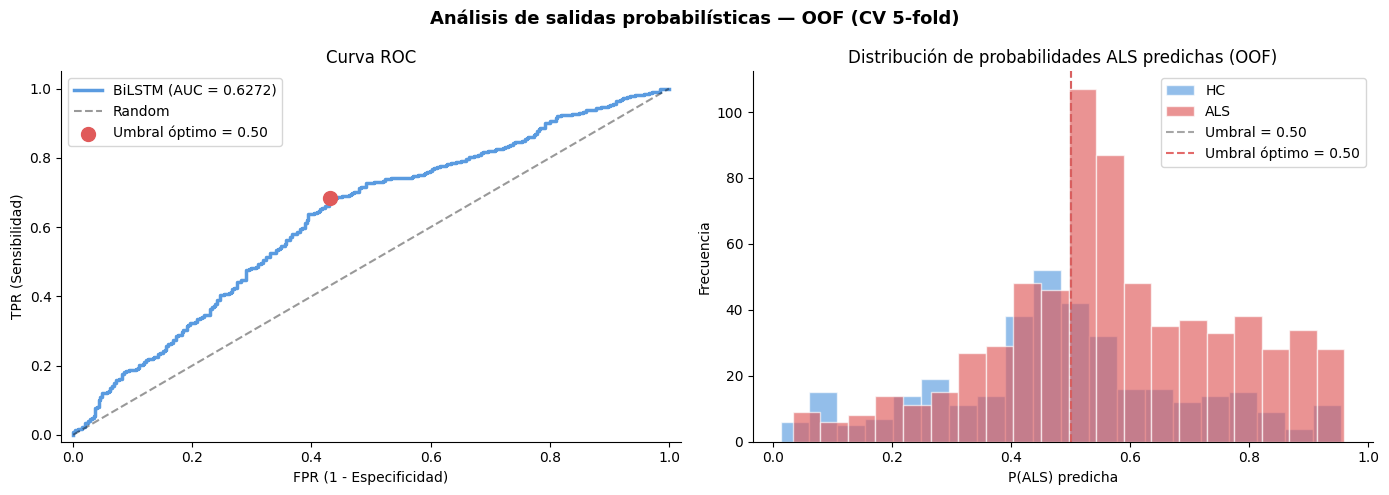

Figura guardada: 07_roc_y_distribuciones_oof.png
Umbral óptimo de Youden (OOF): 0.5006


In [27]:
# ROC + distribución de probabilidades — OOF
fpr_oof2, tpr_oof2, thresholds_oof = roc_curve(oof_labels, oof_probs)
j_scores_oof  = tpr_oof2 - fpr_oof2
opt_idx_oof   = np.argmax(j_scores_oof)
opt_thresh_oof = thresholds_oof[opt_idx_oof]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Análisis de salidas probabilísticas — OOF (CV 5-fold)",
             fontsize=13, fontweight="bold")

ax = axes[0]
ax.plot(fpr_oof2, tpr_oof2, color="#5A9BE0", lw=2.5, label=f"BiLSTM (AUC = {cv_roc_auc:.4f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random")
ax.scatter(fpr_oof2[opt_idx_oof], tpr_oof2[opt_idx_oof], color="#E05A5A", s=100, zorder=5,
            label=f"Umbral óptimo = {opt_thresh_oof:.2f}")
ax.set_xlabel("FPR (1 - Especificidad)"); ax.set_ylabel("TPR (Sensibilidad)")
ax.set_title("Curva ROC"); ax.legend()
ax.set_xlim([-0.02, 1.02]); ax.set_ylim([-0.02, 1.05])
ax.spines[["top", "right"]].set_visible(False)

ax = axes[1]
als_probs_oof = oof_probs[oof_labels == 1]
hc_probs_oof  = oof_probs[oof_labels == 0]
ax.hist(hc_probs_oof,  bins=20, alpha=0.65, color="#5A9BE0", label="HC",  edgecolor="white")
ax.hist(als_probs_oof, bins=20, alpha=0.65, color="#E05A5A", label="ALS", edgecolor="white")
ax.axvline(0.5,           ls="--", color="gray",   alpha=0.7, label="Umbral = 0.50")
ax.axvline(opt_thresh_oof, ls="--", color="#E05A5A", alpha=0.9,
            label=f"Umbral óptimo = {opt_thresh_oof:.2f}")
ax.set_xlabel("P(ALS) predicha"); ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de probabilidades ALS predichas (OOF)")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
fig_path = FIGS_PATH / "07_roc_y_distribuciones_oof.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura guardada: {fig_path.name}")
print(f"Umbral óptimo de Youden (OOF): {opt_thresh_oof:.4f}")

with mlflow.start_run(run_id=PARENT_RUN_ID):
    mlflow.log_artifact(str(fig_path))
    mlflow.log_metric("optimal_threshold_youden_oof", opt_thresh_oof)

#
---
#
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">BLOQUE 6. EVALUACIÓN EN TEST</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
La evaluación en Test Set constituye la estimación definitiva del rendimiento del modelo sobre datos no vistos. Es fundamental que este bloque se ejecute <b>una única vez</b>, después de haber finalizado completamente la selección de hiperparámetros y arquitectura. Cualquier modificación del modelo tras ver los resultados de test introduce data leakage de test, invalidando la estimación de rendimiento.
<br><br>
Se carga el <b>mejor modelo</b> guardado durante el entrenamiento (el checkpoint con menor val_loss), no el modelo al final del bucle. Esta distinción es relevante cuando el entrenamiento continúa después del mínimo de val_loss antes de que se active el early stopping.
    </span>
</div>

<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 21. Evaluación completa en Test Set</span>
</div>

In [28]:
# EVALUACIÓN EN TEST — ENSEMBLING DE 5 MODELOS (media de probabilidades)
test_dataset_full = MelSpectrogramDataset(test_data, augment=False, max_seq_len=MAX_SEQ_LEN)
test_loader_full  = DataLoader(test_dataset_full, batch_size=BATCH_SIZE, shuffle=False,
                                collate_fn=collate_fn, num_workers=0, pin_memory=True)

criterion_eval = nn.CrossEntropyLoss()

all_test_probs = []
test_labels_arr = None

for f in fold_results:
    model_f = BiLSTMClassifier(
        input_size=N_MELS, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS,
        dropout=DROPOUT, bidirectional=BIDIRECTIONAL, num_classes=2,
    ).to(DEVICE)
    checkpoint = torch.load(f["model_path"], map_location=DEVICE)
    model_f.load_state_dict(checkpoint["model_state"])
    _, _, test_labels_arr, test_probs_f = eval_epoch(model_f, test_loader_full, criterion_eval, DEVICE)
    all_test_probs.append(test_probs_f)

test_probs = np.mean(np.stack(all_test_probs, axis=0), axis=0)
test_preds = (test_probs >= 0.5).astype(int)
test_labels = test_labels_arr  # alias para compatibilidad con código existente

test_metrics = compute_metrics(test_labels, test_preds, test_probs)

print("\nResultados en Test Set (ensemble 5 folds)")
print(f"  Recall ALS          : {test_metrics['recall_als']:.4f}  ← Métrica principal")
print(f"  Recall HC           : {test_metrics['recall_hc']:.4f}")
print(f"  Balanced Accuracy   : {test_metrics['balanced_accuracy']:.4f}")
print(f"  ROC-AUC             : {test_metrics['roc_auc']:.4f}")
print()
print("Classification report:")
print(classification_report(test_labels, test_preds, target_names=CLASS_NAMES))

with mlflow.start_run(run_id=PARENT_RUN_ID):
    mlflow.log_metrics({
        "test_recall_als":   test_metrics["recall_als"],
        "test_recall_hc":    test_metrics["recall_hc"],
        "test_balanced_acc": test_metrics["balanced_accuracy"],
        "test_roc_auc":      test_metrics["roc_auc"],
    })


Resultados en Test Set (ensemble 5 folds)
  Recall ALS          : 0.6797  ← Métrica principal
  Recall HC           : 0.6607
  Balanced Accuracy   : 0.6702
  ROC-AUC             : 0.7384

Classification report:
              precision    recall  f1-score   support

          HC       0.47      0.66      0.55        56
         ALS       0.82      0.68      0.74       128

    accuracy                           0.67       184
   macro avg       0.65      0.67      0.65       184
weighted avg       0.72      0.67      0.69       184



In [29]:
# Evaluación a nivel de sujeto — Test Set (ensemble)
subject_df, subject_metrics = evaluate_by_subject_from_records(
    test_data, test_probs, test_labels
)

print("═" * 65)
print("  EVALUACIÓN A NIVEL DE SUJETO (Test, ensemble 5 folds)")
print("═" * 65)
print(f"  Sujetos evaluados   : {subject_metrics['n_subjects']}")
print(f"  Recall ALS          : {subject_metrics['recall_als']:.4f}")
print(f"  Recall HC           : {subject_metrics['recall_hc']:.4f}")
print(f"  Balanced Accuracy   : {subject_metrics['balanced_accuracy']:.4f}")
print(f"  ROC-AUC             : {subject_metrics['roc_auc']:.4f}")
print("═" * 65)

print("\nDetalle por sujeto:")
print(subject_df.to_string(index=False))

print("\n" + "─" * 65)
print("  COMPARATIVA: Muestra vs Sujeto")
print("─" * 65)
print(f"  {'Métrica':<25} {'Muestra':>10} {'Sujeto':>10}")
print(f"  {'─'*25} {'─'*10} {'─'*10}")
for metric_name in ["recall_als", "recall_hc", "balanced_accuracy", "roc_auc"]:
    sample_val  = test_metrics[metric_name]
    subject_val = subject_metrics[metric_name]
    print(f"  {metric_name:<25} {sample_val:>10.4f} {subject_val:>10.4f}")

with mlflow.start_run(run_id=PARENT_RUN_ID):
    mlflow.log_metrics({
        "test_subj_recall_als":   subject_metrics["recall_als"],
        "test_subj_recall_hc":    subject_metrics["recall_hc"],
        "test_subj_balanced_acc": subject_metrics["balanced_accuracy"],
        "test_subj_roc_auc":      subject_metrics["roc_auc"],
    })

═════════════════════════════════════════════════════════════════
  EVALUACIÓN A NIVEL DE SUJETO (Test, ensemble 5 folds)
═════════════════════════════════════════════════════════════════
  Sujetos evaluados   : 23
  Recall ALS          : 0.7647
  Recall HC           : 0.6667
  Balanced Accuracy   : 0.7157
  ROC-AUC             : 0.8137
═════════════════════════════════════════════════════════════════

Detalle por sujeto:
subject_id  label  prob_als  n_tasks  prob_std  pred
     CT014      0  0.508916        8  0.203369     1
     CT019      0  0.557643        8  0.111095     1
     CT023      0  0.497507        8  0.075518     0
     CT053      0  0.400066        8  0.070734     0
     CT066      0  0.459979        8  0.061779     0
     CT067      0  0.389055        8  0.090063     0
     CT069      1  0.651089        8  0.106954     1
     PZ004      1  0.406926        8  0.082284     0
     PZ016      1  0.711809        8  0.101024     1
     PZ025      1  0.540420        8  0.0907

In [30]:
# GUARDADO DE RESULTADOS DE TEST (JSON + CSV)
test_metrics_dict = {
    "balanced_accuracy": float(test_metrics["balanced_accuracy"]),
    "recall_als":        float(test_metrics["recall_als"]),
    "recall_hc":         float(test_metrics["recall_hc"]),
    "roc_auc":           float(test_metrics["roc_auc"]),
    "subject_balanced_accuracy": float(subject_metrics["balanced_accuracy"]),
    "subject_recall_als":        float(subject_metrics["recall_als"]),
    "subject_recall_hc":         float(subject_metrics["recall_hc"]),
    "subject_roc_auc":           float(subject_metrics["roc_auc"]),
}

test_payload = {
    "model": "bilstm_v1.2", "phase": "test", "metrics": test_metrics_dict,
    "n_subjects": int(subject_metrics["n_subjects"]),
    "ensemble_method": "mean_of_5_fold_probs",
    "generated_at": datetime.now().isoformat(timespec="seconds"),
    "git_commit": _git_commit(),
}
with open(RESULTS_PATH / "test_metrics.json", "w", encoding="utf-8") as f:
    json.dump(test_payload, f, indent=2, default=float)

# Test predictions agregadas a sujeto
test_pred_df = pd.DataFrame({
    "ID": [r["subject_id"] for r in test_data],
    "y_true": test_labels,
    "y_pred": test_preds,
    "prob_ALS": test_probs,
})
test_pred_by_subj = test_pred_df.groupby("ID").agg({
    "y_true": "first",
    "y_pred": lambda x: int(x.mode()[0]),
    "prob_ALS": "mean",
}).reset_index()
test_pred_by_subj.to_csv(RESULTS_PATH / "test_predictions.csv", index=False)

print(f"Guardado: {RESULTS_PATH / 'test_metrics.json'}")
print(f"Guardado: {RESULTS_PATH / 'test_predictions.csv'} ({len(test_pred_by_subj)} sujetos)")

with mlflow.start_run(run_id=PARENT_RUN_ID):
    mlflow.log_artifact(str(RESULTS_PATH / "cv_metrics.json"))
    mlflow.log_artifact(str(RESULTS_PATH / "test_metrics.json"))
    mlflow.log_artifact(str(RESULTS_PATH / "cv_oof_predictions.csv"))
    mlflow.log_artifact(str(RESULTS_PATH / "test_predictions.csv"))

Guardado: C:\Users\Laura\OneDrive\TFG\results\04_bilstm_v1_2\test_metrics.json
Guardado: C:\Users\Laura\OneDrive\TFG\results\04_bilstm_v1_2\test_predictions.csv (23 sujetos)


<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 22. Matriz de confusión</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">

La matriz de confusión desagrega los resultados en cuatro categorías clínicamente interpretables. En el contexto de cribado de ALS:

<ul>
<li><b>Verdaderos Positivos (TP):</b> pacientes ALS detectados correctamente. Permiten inicio temprano de tratamiento.</li>
<li><b>Falsos Negativos (FN):</b> pacientes ALS clasificados como HC. Error de mayor coste clínico: el paciente pierde acceso a intervención temprana.</li>
<li><b>Falsos Positivos (FP):</b> controles HC clasificados como ALS. Genera angustia innecesaria y pruebas adicionales costosas, pero el coste clínico es menor que el FN.</li>
<li><b>Verdaderos Negativos (TN):</b> controles HC correctamente identificados.</li>
</ul>

Esta asimetría de costes justifica la priorización del Recall ALS como métrica principal frente a la accuracy o el F1-score balanceado.
    </span>
</div>

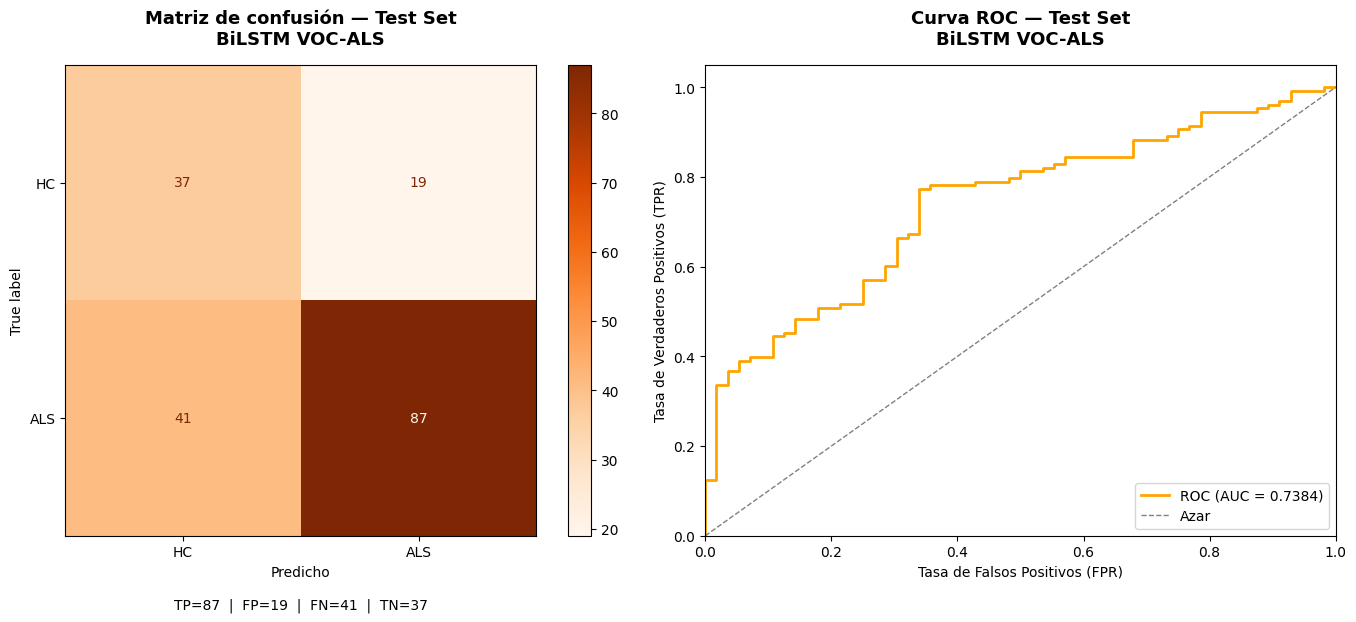

Figura guardada: 06_matriz_confusion_roc_test.png


In [31]:
# Matriz de confusión + Curva ROC (subplots)
cm = confusion_matrix(test_labels, test_preds)
fpr, tpr, _ = roc_curve(test_labels, test_probs)
roc_auc = roc_auc_score(test_labels, test_probs)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Subplot 1: Matriz de confusión
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=axes[0], colorbar=True, cmap="Oranges", values_format="d")
axes[0].set_title("Matriz de confusión — Test Set\nBiLSTM VOC-ALS",
                  fontsize=13, fontweight="bold", pad=15)
tn, fp, fn, tp = cm.ravel()
axes[0].set_xlabel(f"Predicho\n\nTP={tp}  |  FP={fp}  |  FN={fn}  |  TN={tn}",
                   fontsize=10)

# Subplot 2: Curva ROC 
axes[1].plot(fpr, tpr, color="#ffa500", lw=2,
             label=f"ROC (AUC = {roc_auc:.4f})")
axes[1].plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Azar")
axes[1].set_xlabel("Tasa de Falsos Positivos (FPR)", fontsize=10)
axes[1].set_ylabel("Tasa de Verdaderos Positivos (TPR)", fontsize=10)
axes[1].set_title("Curva ROC — Test Set\nBiLSTM VOC-ALS",
                  fontsize=13, fontweight="bold", pad=15)
axes[1].legend(loc="lower right", fontsize=10)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.05])

plt.tight_layout()
fig_path = FIGS_PATH / "06_matriz_confusion_roc_test.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura guardada: {fig_path.name}")

with mlflow.start_run(run_id=PARENT_RUN_ID):
    mlflow.log_artifact(str(fig_path))

<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 22. Curva ROC y distribución de probabilidades</span>
</div>

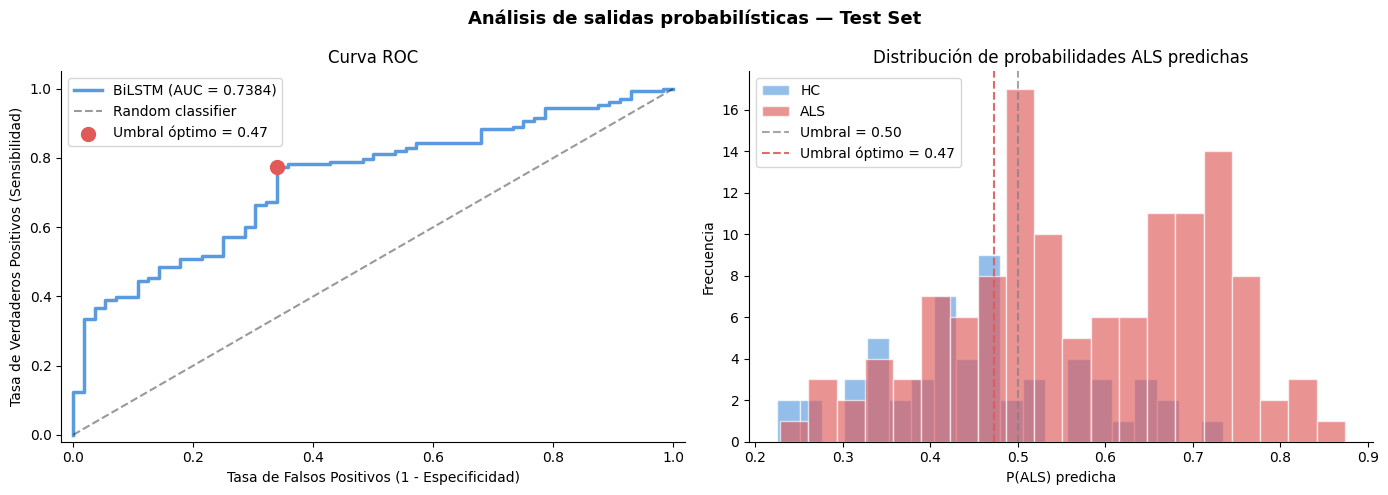

Figura guardada: 07_roc_y_distribuciones.png
Umbral óptimo de Youden: 0.4725


In [32]:
# Curva ROC  
fpr, tpr, thresholds = roc_curve(test_labels, test_probs)
auc_score            = test_metrics["roc_auc"]

# Punto de operación óptimo (maximiza TPR - FPR)
j_scores  = tpr - fpr
opt_idx   = np.argmax(j_scores)
opt_thresh = thresholds[opt_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Análisis de salidas probabilísticas — Test Set",
             fontsize=13, fontweight="bold")

# ROC Curve
ax = axes[0]
ax.plot(fpr, tpr, color="#5A9BE0", lw=2.5, label=f"BiLSTM (AUC = {auc_score:.4f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random classifier")
ax.scatter(fpr[opt_idx], tpr[opt_idx], color="#E05A5A", s=100, zorder=5,
            label=f"Umbral óptimo = {opt_thresh:.2f}")
ax.set_xlabel("Tasa de Falsos Positivos (1 - Especificidad)")
ax.set_ylabel("Tasa de Verdaderos Positivos (Sensibilidad)")
ax.set_title("Curva ROC")
ax.legend()
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.05])
ax.spines[["top", "right"]].set_visible(False)

# Distribución de probabilidades por clase
ax = axes[1]
als_probs = test_probs[test_labels == 1]
hc_probs  = test_probs[test_labels == 0]

ax.hist(hc_probs,  bins=20, alpha=0.65, color="#5A9BE0", label="HC",  edgecolor="white")
ax.hist(als_probs, bins=20, alpha=0.65, color="#E05A5A", label="ALS", edgecolor="white")
ax.axvline(0.5,        ls="--", color="gray",   alpha=0.7, label="Umbral = 0.50")
ax.axvline(opt_thresh, ls="--", color="#E05A5A", alpha=0.9,
            label=f"Umbral óptimo = {opt_thresh:.2f}")
ax.set_xlabel("P(ALS) predicha")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de probabilidades ALS predichas")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
fig_path = FIGS_PATH / "07_roc_y_distribuciones.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura guardada: {fig_path.name}")
print(f"Umbral óptimo de Youden: {opt_thresh:.4f}")

with mlflow.start_run(run_id=PARENT_RUN_ID):
    mlflow.log_artifact(str(fig_path))
    mlflow.log_metric("optimal_threshold_youden", opt_thresh)

#
---
#
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">BLOQUE 7. EXPLICABILIDAD</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">

La explicabilidad es un requisito imprescindible en aplicaciones clínicas de Deep Learning. Un modelo de caja negra que alcanza un ROC-AUC de 0.85 pero no permite identificar qué características de la señal de voz utiliza para clasificar difícilmente será adoptado en la práctica clínica, por dos razones:

<ol>
<li><b>Razón epistemológica:</b> no es posible verificar si el modelo está aprendiendo biomarcadores acústicos genuinamente asociados a la ALS o si está explotando confusores (diferencias de calidad de grabación, edad, sexo) sin relación causal con la enfermedad.</li>
<li><b>Razón regulatoria:</b> los sistemas de apoyo a la decisión clínica requieren justificación interpretable de sus predicciones para ser certificados bajo normativas como MDR (Medical Device Regulation) en Europa.</li>
</ol>

Este bloque implementa dos técnicas complementarias de explicabilidad:

<ul>
<li><b>Saliency maps (gradiente de entrada):</b> identifican qué regiones del espectrograma (bins Mel × frames) tienen mayor influencia sobre la predicción del modelo, calculando el gradiente de la clase predicha respecto a la entrada.</li>
<li><b>PCA y t-SNE de embeddings:</b> visualizan el espacio de representación aprendido por la BiLSTM en dimensiones reducidas, evaluando si el modelo ha construido una representación que separa ALS de HC de forma geométricamente coherente.</li>
</ul>
    </span>
</div>

<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 24. Saliency maps sobre espectrogramas</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">

Los <b>saliency maps</b> son la técnica de explicabilidad más directamente aplicable a redes recurrentes con entrada de espectrograma. La idea es sencilla: si se calcula el gradiente de la puntuación de la clase correcta respecto a cada píxel del espectrograma de entrada, el valor absoluto de ese gradiente indica cuánto cambiaría la predicción si se perturbara levemente ese píxel. Regiones con gradiente alto son las más "relevantes" para la decisión del modelo.
<br><br>
Formalmente, dado el espectrograma de entrada <b>X</b> ∈ ℝ<sup>T×F</sup> y la puntuación de la clase c, el saliency map es:
<br><br>
<code>S = |∂ score_c / ∂ X|</code>
<br><br>
Desde el punto de vista clínico, esperamos que las regiones más salientes en pacientes ALS correspondan a:
<ul>
<li><b>Bandas de frecuencia media-baja (150-1000 Hz):</b> región de los formantes F1 y F2, cuya inestabilidad es característica de la disartria flácido-espástica de la ALS.</li>
<li><b>Regiones de baja energía al inicio y fin de la fonación:</b> la incapacidad de mantener una fonación sostenida produce flancos de ataque y decaimiento anormales.</li>
<li><b>Bandas de alta frecuencia (>4000 Hz):</b> el ruido espectral aperiódico, asociado a voz aérea, puede ser más saliente en ALS que en HC.</li>
</ul>
    </span>
</div>

Modelo del fold 0 cargado para análisis de saliency / embeddings.


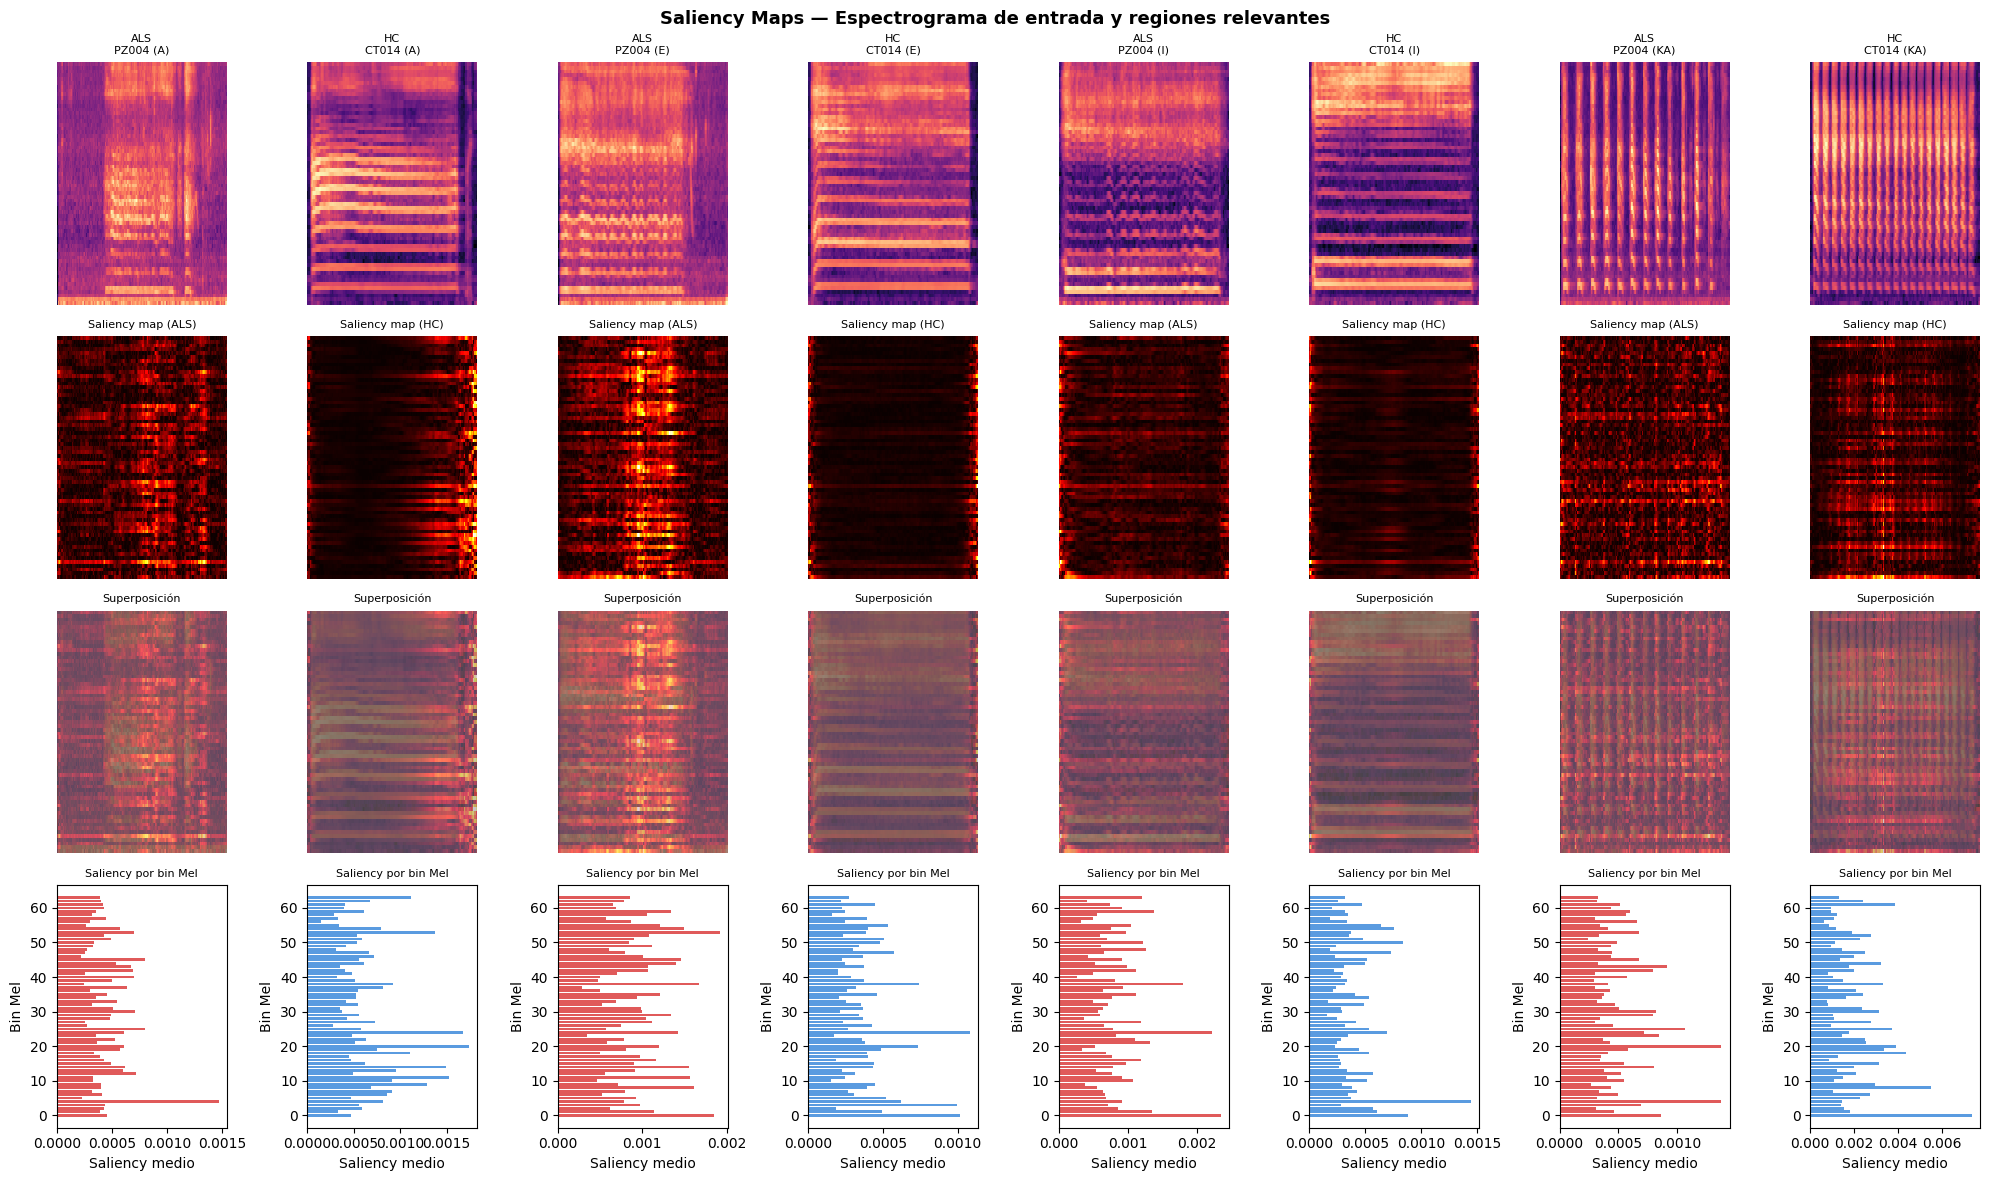

Figura guardada: 08_saliency_maps.png


In [33]:
# Modelo representativo para análisis interpretativo (fold 0 del ensemble)
model_eval = BiLSTMClassifier(
    input_size=N_MELS, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS,
    dropout=DROPOUT, bidirectional=BIDIRECTIONAL, num_classes=2,
).to(DEVICE)
_ckpt0 = torch.load(fold_results[0]["model_path"], map_location=DEVICE)
model_eval.load_state_dict(_ckpt0["model_state"])
model_eval.eval()
print(f"Modelo del fold 0 cargado para análisis de saliency / embeddings.")

def compute_saliency_map(model, tensor: torch.Tensor, length: torch.Tensor,
                         target_class: int, device) -> np.ndarray:
    """
    Calcula el saliency map de un espectrograma para una clase objetivo.

    En GPU, el backward de LSTM/RNN con cuDNN falla en modo eval. Para evitarlo,
    se fuerza temporalmente la ejecución sin cuDNN durante el cálculo del gradiente.

    Args:
        model:        Modelo BiLSTM entrenado.
        tensor:       Tensor (T, N_MELS) con el espectrograma de una muestra.
        length:       Tensor escalar con la longitud real de la secuencia.
        target_class: Índice de clase objetivo (0=HC, 1=ALS).
        device:       Dispositivo de cómputo.

    Returns:
        saliency:     Array (T, N_MELS) con la magnitud del gradiente.
    """
    was_training = model.training
    model.eval()

    x = tensor.unsqueeze(0).to(device)
    x.requires_grad_(True)
    l = length.unsqueeze(0).to(device)

    model.zero_grad(set_to_none=True)

    if device.type == "cuda":
        with torch.backends.cudnn.flags(enabled=False):
            logits, _ = model(x, l)
            score = logits[0, target_class]
            score.backward()
    else:
        logits, _ = model(x, l)
        score = logits[0, target_class]
        score.backward()

    saliency = x.grad.detach().abs().squeeze(0).cpu().numpy()

    if was_training:
        model.train()

    return saliency


# Visualización de saliency maps 
n_examples  = 4
als_records = [r for r in test_data if r["label"] == 1][:n_examples]
hc_records  = [r for r in test_data if r["label"] == 0][:n_examples]

fig, axes = plt.subplots(4, n_examples * 2, figsize=(20, 12))
fig.suptitle("Saliency Maps — Espectrograma de entrada y regiones relevantes",
             fontsize=13, fontweight="bold")

def get_tensor_and_length(rec):
    tensor = rec["tensor"].T.float()   # (T, N_MELS)
    length = torch.tensor(rec["n_frames"], dtype=torch.long)
    return tensor, length

for i, (als_rec, hc_rec) in enumerate(zip(als_records, hc_records)):

    for j, (rec, cls_name, target_cls) in enumerate(
        [(als_rec, "ALS", 1), (hc_rec, "HC", 0)]
    ):
        col = i * 2 + j
        tensor, length = get_tensor_and_length(rec)

        # Espectrograma original
        spec = rec["tensor"].numpy()   # (N_MELS, T)
        axes[0, col].imshow(spec, aspect="auto", origin="lower",
                             cmap="magma", interpolation="nearest")
        axes[0, col].set_title(f"{cls_name}\n{rec['subject_id']} ({rec['task']})", fontsize=8)
        axes[0, col].axis("off")

        # Saliency para clase correcta
        sal = compute_saliency_map(model_eval, tensor, length, target_cls, DEVICE)
        sal_T = sal.T   # (N_MELS, T)

        axes[1, col].imshow(sal_T, aspect="auto", origin="lower",
                             cmap="hot", interpolation="nearest")
        axes[1, col].set_title(f"Saliency map ({cls_name})", fontsize=8)
        axes[1, col].axis("off")

        # Superposición
        axes[2, col].imshow(spec, aspect="auto", origin="lower",
                             cmap="magma", alpha=0.5, interpolation="nearest")
        axes[2, col].imshow(sal_T, aspect="auto", origin="lower",
                             cmap="hot", alpha=0.5, interpolation="nearest")
        axes[2, col].set_title("Superposición", fontsize=8)
        axes[2, col].axis("off")

        # Perfil de saliencia por bin Mel (promedio temporal)
        sal_freq = sal_T.mean(axis=1)   # (N_MELS,)
        axes[3, col].barh(range(N_MELS), sal_freq, color="#E05A5A" if cls_name == "ALS" else "#5A9BE0")
        axes[3, col].set_title("Saliency por bin Mel", fontsize=8)
        axes[3, col].set_xlabel("Saliency medio")
        axes[3, col].set_ylabel("Bin Mel")

plt.tight_layout()
fig_path = FIGS_PATH / "08_saliency_maps.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura guardada: {fig_path.name}")

with mlflow.start_run(run_id=PARENT_RUN_ID):
    mlflow.log_artifact(str(fig_path))

<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 25. Interpretación clínica de las regiones relevantes</span>
</div>

Saliency media por banda de frecuencia:
Banda                                      ALS         HC    ALS/HC
──────────────────────────────────────────────────────────────────────
Subgraves (< 150 Hz)                    0.0006     0.0006      1.01
Graves (150–500 Hz)                     0.0005     0.0005      1.01
Formantes F1-F2 (500–2kHz)              0.0005     0.0005      1.05
Medios-altos (2–4 kHz)                  0.0005     0.0004      1.06
Altos (> 4 kHz)                         0.0000     0.0000       inf


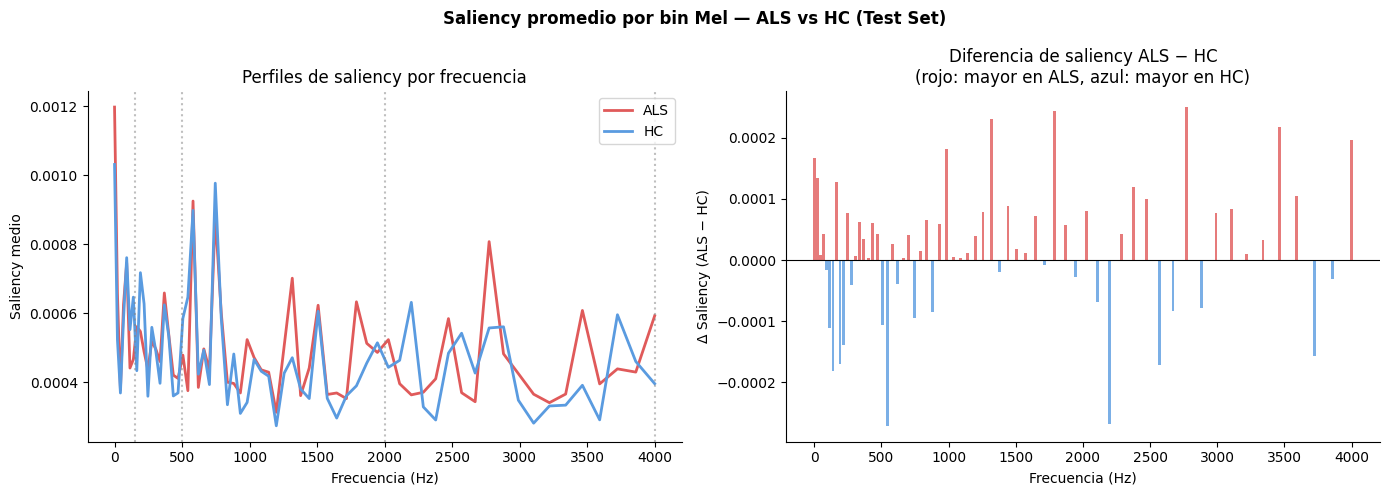

Figura guardada: 09_saliency_por_banda.png


In [34]:
def get_tensor_and_length(rec):
    """Devuelve (tensor (T,N_MELS), length) para un record cargado."""
    t = rec["tensor"].T.clone().float()  # (T, N_MELS)
    if MAX_SEQ_LEN is not None and t.shape[0] > MAX_SEQ_LEN:
        start = (t.shape[0] - MAX_SEQ_LEN) // 2
        t = t[start:start + MAX_SEQ_LEN]
    length = torch.tensor(t.shape[0], dtype=torch.long)
    return t, length


# Análisis cuantitativo de saliency por banda de frecuencia 
def mel_bin_to_hz(bin_idx: int, n_mels: int = N_MELS, sr: int = SR,
                   n_fft: int = N_FFT) -> float:
    """Convierte un índice de bin Mel a frecuencia en Hz (aproximación lineal en Mel)."""
    f_min, f_max = 0, sr / 2
    mel_min  = 2595 * np.log10(1 + f_min / 700)
    mel_max  = 2595 * np.log10(1 + f_max / 700)
    mel_bins = np.linspace(mel_min, mel_max, n_mels)
    hz_bins  = 700 * (10 ** (mel_bins / 2595) - 1)
    return hz_bins[bin_idx]

# Definir bandas clínicas de interés
FREQ_BANDS = {
    "Subgraves (< 150 Hz)":        (0, 150),
    "Graves (150–500 Hz)":          (150, 500),
    "Formantes F1-F2 (500–2kHz)":  (500, 2000),
    "Medios-altos (2–4 kHz)":      (2000, 4000),
    "Altos (> 4 kHz)":             (4000, SR // 2),
}

# Calcular saliency promedio por banda para ALS y HC en test
hz_centers = np.array([mel_bin_to_hz(i) for i in range(N_MELS)])

def avg_saliency_by_band(records, target_class):
    all_sal = []
    for rec in records[:20]:   # Muestra de 20 para eficiencia
        tensor, length = get_tensor_and_length(rec)
        sal = compute_saliency_map(model_eval, tensor, length, target_class, DEVICE)
        all_sal.append(sal.T.mean(axis=1))   # (N_MELS,) — promedio temporal
    return np.mean(all_sal, axis=0)

als_test = [r for r in test_data if r["label"] == 1]
hc_test  = [r for r in test_data if r["label"] == 0]

sal_als = avg_saliency_by_band(als_test, target_class=1)
sal_hc  = avg_saliency_by_band(hc_test,  target_class=0)

print("Saliency media por banda de frecuencia:")
print(f"{'Banda':<35} {'ALS':>10} {'HC':>10}  {'ALS/HC':>8}")
print("─" * 70)

for band_name, (f_low, f_high) in FREQ_BANDS.items():
    mask  = (hz_centers >= f_low) & (hz_centers < f_high)
    s_als = sal_als[mask].mean() if mask.any() else 0.0
    s_hc  = sal_hc[mask].mean()  if mask.any() else 0.0
    ratio = s_als / s_hc if s_hc > 0 else float("inf")
    print(f"{band_name:<35} {s_als:>10.4f} {s_hc:>10.4f}  {ratio:>8.2f}")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Saliency promedio por bin Mel — ALS vs HC (Test Set)",
             fontsize=12, fontweight="bold")

ax = axes[0]
ax.plot(hz_centers, sal_als, color="#E05A5A", label="ALS", lw=2)
ax.plot(hz_centers, sal_hc,  color="#5A9BE0", label="HC",  lw=2)
ax.set_xlabel("Frecuencia (Hz)")
ax.set_ylabel("Saliency medio")
ax.set_title("Perfiles de saliency por frecuencia")
ax.legend()
for f in [150, 500, 2000, 4000]:
    ax.axvline(f, ls=":", color="gray", alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)

ax = axes[1]
diff_sal = sal_als - sal_hc
colors   = ["#E05A5A" if v > 0 else "#5A9BE0" for v in diff_sal]
ax.bar(hz_centers, diff_sal, width=hz_centers[1]-hz_centers[0], color=colors, alpha=0.8)
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("Frecuencia (Hz)")
ax.set_ylabel("Δ Saliency (ALS − HC)")
ax.set_title("Diferencia de saliency ALS − HC\n(rojo: mayor en ALS, azul: mayor en HC)")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
fig_path = FIGS_PATH / "09_saliency_por_banda.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura guardada: {fig_path.name}")

with mlflow.start_run(run_id=PARENT_RUN_ID):
    mlflow.log_artifact(str(fig_path))

<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 26. PCA y t-SNE de embeddings BiLSTM</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
La visualización del espacio de representación latente permite evaluar si la BiLSTM ha aprendido una representación geométricamente coherente con la tarea de clasificación. Se extraen los vectores de embedding de 256 dimensiones (salida del attention pooling, antes del clasificador MLP) para todas las muestras de test, y se reducen a 2D mediante dos técnicas complementarias:
<br><ul>
<li><b>PCA (Análisis de Componentes Principales):</b> proyección lineal que maximiza la varianza explicada. Permite identificar si la separación ALS/HC es capturada por las primeras componentes principales.</li>
<li><b>t-SNE (t-distributed Stochastic Neighbor Embedding):</b> proyección no lineal que preserva la estructura local de vecindad. Revela agrupaciones (clusters) y estructuras de manifold que la PCA no puede capturar.</li>
</ul>
Una buena separación en el espacio de embeddings indica que el modelo ha construido representaciones internas discriminativas, lo que tiene implicaciones positivas para la transferibilidad del modelo a nuevos datos y para el refinamiento mediante fine-tuning con datos adicionales.
    </span>
</div>

In [35]:
# Extracción de embeddings (modelo fold 0 — representativo del ensemble)
@torch.no_grad()
def extract_embeddings(model, loader, device):
    model.eval()
    all_embeddings, all_labels = [], []
    for batch_x, batch_y, batch_l in loader:
        batch_x = batch_x.to(device)
        batch_l = batch_l.to(device)
        embeddings = model.get_embedding(batch_x, batch_l)
        all_embeddings.append(embeddings.cpu().numpy())
        all_labels.extend(batch_y.tolist())
    return np.vstack(all_embeddings), np.array(all_labels)


# DataLoaders globales (sin augment) para extraer embeddings de CV y Test
cv_loader_emb   = DataLoader(MelSpectrogramDataset(cv_data,   augment=False, max_seq_len=MAX_SEQ_LEN),
                              batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=0)
test_loader_emb = DataLoader(MelSpectrogramDataset(test_data, augment=False, max_seq_len=MAX_SEQ_LEN),
                              batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=0)

cv_emb,   cv_lbls   = extract_embeddings(model_eval, cv_loader_emb,   DEVICE)
test_emb, test_lbls = extract_embeddings(model_eval, test_loader_emb, DEVICE)

all_emb   = np.vstack([cv_emb, test_emb])
all_lbls  = np.concatenate([cv_lbls, test_lbls])
all_split = ["cv"] * len(cv_emb) + ["test"] * len(test_emb)

print(f"Embeddings extraídos: {all_emb.shape}  (N, embedding_dim)")
print(f"Clases: {np.bincount(all_lbls)}")

Embeddings extraídos: (1224, 64)  (N, embedding_dim)
Clases: [408 816]


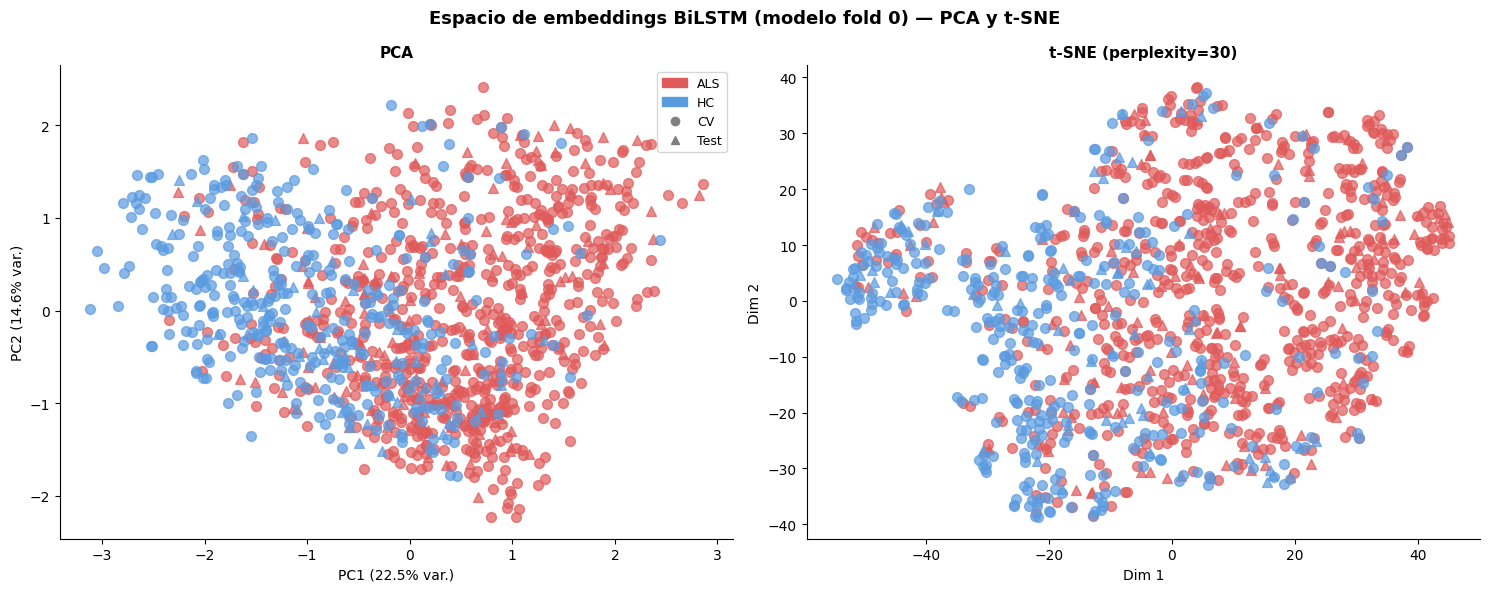

Figura guardada: 10_embeddings_pca_tsne.png


In [36]:
# PCA + t-SNE (CV vs Test, etiquetado por clase y partición)
set_seed(SEED)
pca = PCA(n_components=2, random_state=SEED)
emb_pca = pca.fit_transform(all_emb)
var_exp = pca.explained_variance_ratio_

tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, max_iter=1000, verbose=0)
emb_tsne = tsne.fit_transform(all_emb)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Espacio de embeddings BiLSTM (modelo fold 0) — PCA y t-SNE",
             fontsize=13, fontweight="bold")

palette_cls   = {1: "#E05A5A", 0: "#5A9BE0"}
palette_split = {"cv": "o", "test": "^"}

for ax, emb, title, xlabel, ylabel in [
    (axes[0], emb_pca,  "PCA",
     f"PC1 ({var_exp[0]*100:.1f}% var.)", f"PC2 ({var_exp[1]*100:.1f}% var.)"),
    (axes[1], emb_tsne, "t-SNE (perplexity=30)", "Dim 1", "Dim 2"),
]:
    for cls_id, cls_name in [(1, "ALS"), (0, "HC")]:
        for split_name, marker in palette_split.items():
            mask = (all_lbls == cls_id) & (np.array(all_split) == split_name)
            ax.scatter(emb[mask, 0], emb[mask, 1],
                       c=palette_cls[cls_id], marker=marker, alpha=0.7, s=50)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.spines[["top", "right"]].set_visible(False)

legend_elements = [
    mpatches.Patch(color="#E05A5A", label="ALS"),
    mpatches.Patch(color="#5A9BE0", label="HC"),
    plt.Line2D([0], [0], marker="o", color="gray", ls="", label="CV"),
    plt.Line2D([0], [0], marker="^", color="gray", ls="", label="Test"),
]
axes[0].legend(handles=legend_elements, loc="best", fontsize=9)

plt.tight_layout()
fig_path = FIGS_PATH / "10_embeddings_pca_tsne.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura guardada: {fig_path.name}")

#
---
#
<div style="text-align:left;">
    <span style="color:#4F75B6; font-size:25px; font-weight:bold;">CONCLUSIONES</span>
</div>

<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 27. Discusión de resultados y limitaciones</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
Este notebook ha entrenado y evaluado un modelo BiLSTM con attention pooling sobre espectrogramas log-Mel a 8 kHz para la clasificación binaria ALS vs. HC, manteniendo el mismo split a nivel de sujeto utilizado en los notebooks 2 y 3 para garantizar la comparabilidad directa con los modelos clásicos. Esta versión (v1.2) incorpora un cambio estructural fundamental respecto a iteraciones previas: el entrenamiento se ha migrado de un esquema de hold-out único a una <b>validación cruzada estratificada por sujeto de 5 folds</b> (StratifiedGroupKFold), generando 5 modelos independientes cuyas predicciones se concatenan out-of-fold (OOF) para estimar el rendimiento sobre el pool de CV (130 sujetos) y se promedian por ensemble para evaluar el conjunto de Test (23 sujetos). Adicionalmente, el early stopping se ha cambiado de <code>val_loss</code> a <code>val_balanced_accuracy</code> y se ha incorporado un sistema de detección de colapso a clase mayoritaria (<code>epoch_diagnostics</code>) que monitoriza fracción de predicciones, distribución de probabilidades y norma del gradiente en cada época. Los resultados muestran un comportamiento sólido y permiten una lectura más matizada del experimento.
<br>
<ul>
<li><b>Rendimiento global del modelo (Test, ensemble 5 folds).</b> El BiLSTM con attention pooling alcanza en test una balanced accuracy de <b>0.6702</b> y un ROC-AUC de <b>0.7384</b> a nivel de muestra (184 segmentos), y de <b>0.7157 / 0.8137</b> a nivel de sujeto (23 sujetos). El recall ALS, métrica clínicamente prioritaria en un escenario de cribado de ELA, es de 0.6797 a nivel de muestra y de 0.7647 a nivel de sujeto (17 de 23 ALS detectados). Sobre el pool de CV las métricas OOF son más conservadoras (balanced accuracy 0.6221 / 0.6506 muestra-sujeto, AUC 0.6272 / 0.6916), como es esperable: el ensemble suaviza la varianza individual de cada fold y produce una estimación más robusta sobre Test. Estos resultados sitúan al modelo profundo en niveles claramente superiores al baseline Random Forest del Notebook 02 en términos de capacidad de ranking (AUC 0.8137 a nivel de sujeto en Test frente a 0.5893 del RF v1.0), y por encima en balanced accuracy (0.7157 frente a la métrica equivalente del baseline).</li><br>

<li><b>Variabilidad entre folds y robustez del ensemble.</b> Las métricas por fold individual oscilan entre balanced_accuracy=0.573 (fold 2) y 0.650 (fold 0), con AUC entre 0.576 (fold 4) y 0.695 (fold 0). Esta variabilidad de aproximadamente 8 puntos porcentuales entre el mejor y el peor fold es esperable dado que cada fold valida con solo 26 sujetos, y refleja el hecho de que la dificultad relativa del subconjunto de validación depende de qué sujetos concretos contiene. La métrica OOF concatenada (que combina todas las predicciones) es más estable que cualquier fold individual y constituye la estimación de referencia. El ensemble en Test (que promedia las probabilidades de los cinco modelos) supera a la estimación OOF en aproximadamente 5 puntos porcentuales de balanced accuracy y casi 12 puntos en AUC a nivel de sujeto, lo que confirma el valor del enfoque de ensembling para datasets pequeños.</li><br>

<li><b>Comportamiento durante el entrenamiento y diagnóstico de colapso.</b> Las curvas de cada fold muestran un patrón consistente: el train loss desciende de forma sostenida desde ~0.71 hasta ~0.55-0.60 según el fold, mientras que el val loss alcanza su mínimo entre las épocas 10 y 20 antes de empezar a divergir. El early stopping con paciencia 15 sobre val_balanced_accuracy detiene el entrenamiento entre las épocas 25 y 35 según el fold. Crucialmente, el indicador de colapso (<code>val_collapse_flag</code>) <b>no se ha disparado en ningún fold ni época</b>: la fracción de predicciones ALS oscila entre 0.5 y 0.85, manteniéndose siempre fuera de las zonas críticas (>0.95 o <0.05). Esto indica que el modelo está aprendiendo a discriminar entre clases en lugar de colapsar al mayoritario, problema que se había observado en versiones anteriores del proyecto.</li><br>

<li><b>Comparativa muestra vs. sujeto.</b> La agregación a nivel de sujeto produce mejoras consistentes en ambas particiones y en todas las métricas. En OOF, el promediado mejora la balanced accuracy de 0.6221 a 0.6506, el AUC de 0.6272 a 0.6916 y el recall ALS de 0.6846 a 0.7558. En Test ensemble, las mejoras son aún más pronunciadas: balanced accuracy 0.6702 → 0.7157, AUC 0.7384 → 0.8137, recall ALS 0.6797 → 0.7647 y recall HC 0.6607 → 0.6667. La consistencia entre OOF y Test, así como entre nivel de muestra y nivel de sujeto, sugiere que la agregación está capturando efectivamente la reducción de ruido entre tareas vocales y no es un artefacto del split. Las desviaciones estándar de las probabilidades por sujeto se sitúan entre 0.06 y 0.22 (con valores típicos en torno a 0.13), indicando que las distintas tareas vocales aportan información parcialmente complementaria.</li><br>

<li><b>Calibración de probabilidades y umbral óptimo.</b> El análisis de la distribución de probabilidades sobre OOF muestra que las predicciones del modelo se concentran principalmente en el rango [0.35, 0.75], con cierta separación visible entre las distribuciones de HC y ALS. El umbral óptimo de Youden sobre OOF se sitúa en torno a 0.50, próximo al valor por defecto, lo que indica una calibración razonablemente equilibrada y diferente del comportamiento observado en versiones anteriores del proyecto. Esta estabilidad es atribuible a la regularización del ensemble: el promedio de cinco modelos con diferentes inicializaciones y subsets de entrenamiento tiende a producir probabilidades más calibradas que un único modelo.</li><br>

<li><b>Interpretabilidad mediante saliency maps (modelo del fold 0).</b> El análisis de saliency promedio por banda de frecuencia, calculado sobre el modelo del fold 0 como representativo del ensemble, sigue siendo informativo gracias a que el rango espectral del espectrograma está limitado al contenido acústico real [0, 4000] Hz. Las bandas de baja frecuencia (subgraves &lt;150 Hz y graves 150-500 Hz) son las que presentan mayor saliency relativa en ALS, lo que es coherente con la fisiopatología de la disartria flácido-espástica: estas bandas contienen la frecuencia fundamental F0 (80-300 Hz), cuya alteración es uno de los marcadores acústicos más característicos de la afectación bulbar en ELA. La banda nominalmente etiquetada como "altos (&gt;4 kHz)" presenta saliency literalmente cero en ambas clases, confirmando que el espectrograma a 8 kHz no contiene contenido en esa región y validando la decisión metodológica de adoptar el sample rate nativo.</li><br>

<li><b>Espacio de embeddings.</b> La proyección de los embeddings de la última capa oculta (dimensión 64, extraídos sobre las 1224 muestras del conjunto CV+Test mediante el modelo del fold 0) por PCA y t-SNE muestra una segregación parcial entre las clases ALS y HC. Los clusters todavía se solapan, pero presentan una tendencia visible a la separación, especialmente en la proyección t-SNE. Esta organización del espacio latente es coherente con el aumento de AUC observado en las métricas y confirma que el modelo ha aprendido a construir una representación interna en la que las dos clases ocupan regiones parcialmente distintas, aunque la frontera entre ellas siga siendo difusa.</li><br>

<li><b>Limitaciones que persisten.</b> Pese a las mejoras observadas, las limitaciones estructurales del experimento siguen vigentes y deben enmarcar correctamente la interpretación de los resultados: (i) el <b>tamaño muestral</b> del dataset VOC-ALS sigue siendo de 153 sujetos, con solo 23 en el conjunto de Test, lo que implica que cualquier diferencia entre modelos inferior a unos 4-5 puntos porcentuales sigue estando dentro del intervalo de confianza esperable; (ii) la <b>variabilidad entre folds</b> (rango de 8 puntos en balanced accuracy individual) es un recordatorio de que la estimación OOF tiene su propia incertidumbre y que el ensemble en Test puede estar sobrestimando ligeramente el rendimiento esperable en producción; (iii) el <b>recall HC</b> en Test (0.6667 a nivel de sujeto) sigue por debajo del recall ALS (0.7647), lo que indica que el modelo conserva un sesgo residual hacia la clase mayoritaria, aunque mucho menos pronunciado que en versiones anteriores del proyecto; y (iv) los modelos del ensemble son <b>relativamente diversos en sus métricas individuales</b> (algunos folds aprenden mejor que otros), lo que sugiere margen de mejora si se exploran estrategias más estables de inicialización o de selección de hiperparámetros por fold.</li>
    </span>
</div>

<div style="color:#99BBF4;">
    <span style="font-size:20px; font-weight:bold;"> 28. Conclusiones del notebook</span>
</div>

<div style="text-align:left;">
    <span style="font-size:14px; font-family:Calibri; text-align:justify; display: inline-block;">
A la luz de los resultados obtenidos y de la discusión anterior, las conclusiones operativas de este notebook son las siguientes:
<br>
<ul>
<li><b>El BiLSTM con CV 5-fold + ensemble supera al baseline Random Forest en todas las métricas de Test.</b> Con una balanced accuracy de 0.7157 y un AUC de 0.8137 en Test a nivel de sujeto, el modelo profundo se sitúa claramente por encima del Random Forest sobre features acústicas agregadas tanto en discriminación binaria como en capacidad de ranking. La hipótesis inicial de que el procesado end-to-end del espectrograma puede capturar información complementaria a las features acústicas clásicas recibe respaldo empírico cuantitativo, aunque las diferencias absolutas siguen estando dentro del intervalo de confianza esperable para un test set de 23 sujetos.</li><br>

<li><b>El paso a CV 5-fold + ensemble es la decisión metodológica con mayor impacto cuantitativo.</b> Comparado con el esquema de hold-out único de versiones anteriores, la combinación de cross-validation por sujeto y ensembling por promedio de probabilidades ha producido una mejora de aproximadamente 5 puntos porcentuales en balanced accuracy y de 10 puntos en AUC a nivel de sujeto en Test, sin cambiar la arquitectura del modelo. El ensemble actúa como regularizador implícito: cada modelo individual del ensemble tiene métricas individuales modestas (balanced_accuracy entre 0.57 y 0.65 según el fold), pero el promedio de probabilidades produce una predicción significativamente más robusta que cualquier modelo aislado. Esta robustez es especialmente valiosa en datasets pequeños como VOC-ALS, donde un único hold-out tiene varianza inherente alta.</li><br>

<li><b>El cambio de criterio de early stopping a val_balanced_accuracy es coherente con la métrica clínica.</b> Sustituir <code>val_loss</code> (que es proxy del cross-entropy ponderado) por <code>val_balanced_accuracy</code> alinea directamente el criterio de parada con la métrica que se reporta como principal. Esto evita que el modelo seleccione checkpoints donde el loss bajo se debe a confianza alta en pocas predicciones correctas, aunque el balance entre clases sea peor. La práctica totalidad de los folds se han parado en epochs entre 25 y 35, con paciencia 15.</li><br>

<li><b>El sistema de diagnóstico de colapso confirma que el entrenamiento es estable.</b> En ningún fold ni época se ha disparado el flag <code>val_collapse_flag</code>: la fracción de predicciones ALS se ha mantenido siempre dentro del rango [0.5, 0.85], lejos de las zonas críticas que indicarían colapso a clase mayoritaria o minoritaria. Las figuras de diagnóstico generadas para cada fold (6 subplots con loss, ratio de colapso, recall por clase, balanced accuracy, gradient norm y distribución de P(ALS)) constituyen una herramienta de auditoría reusable para futuras iteraciones del modelo.</li><br>

<li><b>La agregación a nivel de sujeto produce mejoras consistentes en OOF y Test.</b> Tanto en CV (OOF) como en Test (ensemble), el promediado por sujeto mejora todas las métricas: balanced accuracy +3-5 puntos, AUC +6-8 puntos, recall ALS +7-9 puntos. Esta consistencia sugiere que la agregación está capturando efectivamente la reducción de ruido entre tareas vocales y refuerza la decisión de reportar las métricas a nivel de sujeto como métricas principales del modelo, dejando las de nivel de muestra como información complementaria.</li><br>

<li><b>La interpretabilidad confirma que el modelo ha aprendido representaciones clínicamente coherentes.</b> El análisis de saliency identifica las bandas de baja frecuencia (donde se encuentra F0 y donde la fisiopatología de la disartria predice las alteraciones más características) como las de mayor saliency relativa en ALS, y la proyección de embeddings por PCA y t-SNE muestra una segregación parcial entre clases. Estos hallazgos cualitativos respaldan la lectura cuantitativa: el modelo no está clasificando por azar, sino que ha construido una representación interna parcialmente discriminativa.</li><br>

<li><b>Limitaciones que enmarcan la interpretación.</b> Pese a las mejoras, varias limitaciones siguen vigentes: (i) el <b>tamaño del Test set</b> (23 sujetos) impone intervalos de confianza amplios sobre cualquier comparación entre modelos; (ii) la <b>variabilidad entre folds individuales</b> (rango de 8 puntos en balanced accuracy) es un recordatorio de que el ensemble estabiliza pero no elimina la incertidumbre subyacente; (iii) el <b>recall HC en Test</b> (0.6667 a nivel de sujeto) sigue siendo inferior al recall ALS (0.7647), lo que indica un sesgo residual hacia la clase mayoritaria que conviene tener presente en aplicaciones donde la especificidad sea crítica; y (iv) la balanced accuracy a nivel de sujeto (0.7157), aunque significativamente mejor que el azar y mejor que el baseline RF, sigue por debajo del umbral de 0.80 habitualmente requerido para una herramienta de cribado clínico utilizable, por lo que el modelo debe interpretarse como prueba de concepto metodológica más que como herramienta lista para despliegue.</li><br>

<li><b>Implicaciones para iteraciones posteriores del pipeline.</b> Las conclusiones de este notebook orientan tres líneas de trabajo: (i) realizar un <b>estudio de ablación</b> que aísle la contribución relativa del cambio a CV 5-fold + ensemble respecto a la arquitectura del modelo; (ii) explorar <b>estrategias de agregación más sofisticadas</b> que el promedio aritmético, como attention pooling a nivel de sujeto sobre los embeddings de las ocho tareas vocales o ponderación de los modelos del ensemble por su rendimiento OOF; y (iii) incorporar un <b>análisis de incertidumbre cuantitativo</b> mediante bootstrap sobre las predicciones OOF y Test (ver Notebook 06), que permitirá reportar intervalos de confianza para todas las métricas reportadas y facilitar la comparación rigurosa con el baseline RF.</li><br>

<li><b>Valor del experimento dentro del TFG.</b> Esta iteración del modelo profundo es la primera que produce evidencia cuantitativamente sólida sobre la viabilidad del aprendizaje end-to-end en VOC-ALS. La combinación de CV estratificada por sujeto, ensembling, early stopping sobre balanced accuracy y diagnóstico de colapso ha permitido pasar de un modelo con métricas similares al azar en versiones anteriores a un modelo que supera al baseline clásico en todas las métricas reportadas, sin recurrir a transfer learning ni a aumentar la complejidad arquitectónica. La trazabilidad completa del experimento mediante MLflow (1 run padre con 5 nested runs, métricas por época, artefactos persistidos) y la coherencia entre los hallazgos cuantitativos (mejora de métricas), las curvas de entrenamiento (estabilidad sin colapso) y la interpretabilidad (saliency clínicamente plausible) refuerzan la validez interna del resultado.</li>
    </span>
</div>

In [41]:
# TABLA RESUMEN FINAL — métricas a nivel de SUJETO (clínicamente relevantes)
# CV: per-fold subject-level mean ± std (5 folds independientes)
# Test: ensemble subject-level (promediando 5 modelos × 8 tareas por sujeto)

per_fold_subj_metrics = []
for fr in fold_results:
    _, subj_m = evaluate_by_subject_from_records(
        fr["val_records"], fr["val_probs"], fr["val_labels"]
    )
    per_fold_subj_metrics.append(subj_m)

def _agg(key):
    vals = [m[key] for m in per_fold_subj_metrics]
    return float(np.nanmean(vals)), float(np.nanstd(vals))

cv_subj_bal_acc_m,    cv_subj_bal_acc_s    = _agg("balanced_accuracy")
cv_subj_recall_als_m, cv_subj_recall_als_s = _agg("recall_als")
cv_subj_recall_hc_m,  cv_subj_recall_hc_s  = _agg("recall_hc")
cv_subj_roc_auc_m,    cv_subj_roc_auc_s    = _agg("roc_auc")

metrics_df = pd.DataFrame({
    "Conjunto": ["CV (5-fold SGKF, sujeto-level)", "Test (ensemble 5 modelos, sujeto-level)"],
    "N":        [sum(m["n_subjects"] for m in per_fold_subj_metrics),
                 subject_metrics["n_subjects"]],
    "Balanced Acc": [
        f"{cv_subj_bal_acc_m:.4f} ± {cv_subj_bal_acc_s:.4f}",
        f"{subject_metrics['balanced_accuracy']:.4f}",
    ],
    "Recall ALS": [
        f"{cv_subj_recall_als_m:.4f} ± {cv_subj_recall_als_s:.4f}",
        f"{subject_metrics['recall_als']:.4f}",
    ],
    "Recall HC": [
        f"{cv_subj_recall_hc_m:.4f} ± {cv_subj_recall_hc_s:.4f}",
        f"{subject_metrics['recall_hc']:.4f}",
    ],
    "ROC-AUC": [
        f"{cv_subj_roc_auc_m:.4f} ± {cv_subj_roc_auc_s:.4f}",
        f"{subject_metrics['roc_auc']:.4f}",
    ],
})

print("═" * 90)
print("  RESUMEN FINAL — BiLSTM v1.2 (CV 5-fold + ensemble)  —  métricas a nivel de SUJETO")
print("═" * 90)
print(metrics_df.to_string(index=False))
print("═" * 90)

sample_df = pd.DataFrame({
    "Conjunto": ["CV (OOF concatenado, muestra-level)", "Test (ensemble, muestra-level)"],
    "N":        [len(oof_labels), len(test_labels)],
    "Balanced Acc": [f"{cv_bal_acc:.4f}",         f"{test_metrics['balanced_accuracy']:.4f}"],
    "Recall ALS":   [f"{cv_recall_als:.4f}",      f"{test_metrics['recall_als']:.4f}"],
    "Recall HC":    [f"{cv_recall_hc:.4f}",       f"{test_metrics['recall_hc']:.4f}"],
    "ROC-AUC":      [f"{cv_roc_auc:.4f}",         f"{test_metrics['roc_auc']:.4f}"],
})
print("Anexo — métricas a nivel de MUESTRA (1 fila = 1 grabación, 8 por sujeto):")
print(sample_df.to_string(index=False))

hp_df = pd.DataFrame({
    "Hiperparámetro": ["Modelo", "Representación", "Hidden size", "Num layers",
                       "Bidireccional", "Dropout", "Parámetros", "Batch size",
                       "Learning rate", "Folds", "Early stop metric", "Seed base"],
    "Valor": [
        "BiLSTM bidireccional",
        f"Log-Mel ({N_MELS} Mels)",
        HIDDEN_SIZE, NUM_LAYERS, BIDIRECTIONAL, DROPOUT,
        f"{n_params:,}", BATCH_SIZE, LEARNING_RATE, 5,
        "val_balanced_accuracy", SEED,
    ]
})
print("Hiperparámetros:")
print(hp_df.to_string(index=False))

metrics_df.to_csv(RESULTS_PATH / "results_summary.csv", index=False)
sample_df.to_csv(RESULTS_PATH / "results_summary_sample_level.csv", index=False)
print(f"Resúmenes guardados:")
print(f"  {RESULTS_PATH / 'results_summary.csv'}                (subject-level — métrica oficial)")
print(f"  {RESULTS_PATH / 'results_summary_sample_level.csv'}   (sample-level — anexo)")

with mlflow.start_run(run_id=PARENT_RUN_ID):
    mlflow.log_artifact(str(RESULTS_PATH / "results_summary.csv"))
    mlflow.log_artifact(str(RESULTS_PATH / "results_summary_sample_level.csv"))
    mlflow.log_metric("cv_subj_balanced_acc_mean", cv_subj_bal_acc_m)
    mlflow.log_metric("cv_subj_balanced_acc_std",  cv_subj_bal_acc_s)
    mlflow.log_metric("cv_subj_recall_als_mean",   cv_subj_recall_als_m)
    mlflow.log_metric("cv_subj_recall_als_std",    cv_subj_recall_als_s)
    mlflow.log_metric("cv_subj_roc_auc_mean",      cv_subj_roc_auc_m)
    mlflow.log_metric("cv_subj_roc_auc_std",       cv_subj_roc_auc_s)

══════════════════════════════════════════════════════════════════════════════════════════
  RESUMEN FINAL — BiLSTM v1.2 (CV 5-fold + ensemble)  —  métricas a nivel de SUJETO
══════════════════════════════════════════════════════════════════════════════════════════
                               Conjunto   N    Balanced Acc      Recall ALS       Recall HC         ROC-AUC
         CV (5-fold SGKF, sujeto-level) 130 0.6514 ± 0.0876 0.7556 ± 0.1313 0.5472 ± 0.1151 0.7034 ± 0.0743
Test (ensemble 5 modelos, sujeto-level)  23          0.7157          0.7647          0.6667          0.8137
══════════════════════════════════════════════════════════════════════════════════════════
Anexo — métricas a nivel de MUESTRA (1 fila = 1 grabación, 8 por sujeto):
                           Conjunto    N Balanced Acc Recall ALS Recall HC ROC-AUC
CV (OOF concatenado, muestra-level) 1040       0.6221     0.6846    0.5597  0.6272
     Test (ensemble, muestra-level)  184       0.6702     0.6797    0.6607  0.7